In [1]:
import pandas as pd
import numpy as np
import os
file_path = 'results/f1_scores/combined_f1_scores.csv'

In [2]:
import os

# Create output directory for paper results
ANALYSIS_OUTPUT_DIR = "analysis_results_for_paper"
os.makedirs(ANALYSIS_OUTPUT_DIR, exist_ok=True)

def save_analysis_to_csv(data, filename, description="", additional_info=None):
    """Helper function to save analysis results to CSV with metadata."""
    filepath = os.path.join(ANALYSIS_OUTPUT_DIR, filename)
    
    if additional_info:
        # Add metadata rows at the top
        with open(filepath, 'w') as f:
            f.write("# ANALYSIS METADATA\n")
            for key, value in additional_info.items():
                f.write(f"# {key}: {value}\n")
            f.write("\n")
        
        # Append the actual data
        data.to_csv(filepath, mode='a', index=True)
    else:
        data.to_csv(filepath, index=True)
    
    print(f"💾 Saved: {filepath} - {description}")
    return filepath

def create_verdict(improvement, phase1_score, context=""):
    """Create standardized verdict text."""
    if improvement > 0:
        return f"🟢 LORA HELPS (+{improvement:.4f}, +{improvement/phase1_score*100:.2f}%)"
    elif improvement < 0:
        return f"🔴 LORA HURTS ({improvement:.4f}, {improvement/phase1_score*100:.2f}%)"
    else:
        return "🟡 NO CHANGE"

def create_overall_verdict(improvement, phase1_avg, context=""):
    """Create overall verdict based on improvement."""
    if improvement > 0:
        return f"🟢 Phase 3 (LoRA) performs BETTER than Phase 1 by {improvement:.4f} points"
    elif improvement < 0:
        return f"🔴 Phase 1 (Base) performs BETTER than Phase 3 by {abs(improvement):.4f} points"
    else:
        return f"🟡 Phase 1 and Phase 3 perform equally"

print("✅ Helper functions loaded and output directory created")

✅ Helper functions loaded and output directory created


In [3]:
df = pd.read_csv(file_path)
df.fillna('Not Applicable', inplace=True)
prompt_hierarchy = {
    'vanilla': 1,
    'knowledge_infused': 2,
    'cot': 3,
    'few_shot': 4,
    'cot_knowledge': 5,
    'cot_knowledge_few_shot': 6
}

# Map prompt types to complexity scores
df['prompt_complexity'] = df['prompt_type'].map(prompt_hierarchy)

# Check if any prompt types weren't mapped
unmapped_prompts = df[df['prompt_complexity'].isna()]['prompt_type'].unique()
if len(unmapped_prompts) > 0:
    print(f"⚠️ Warning: Unmapped prompt types found: {unmapped_prompts}")
    # Fill with 0 for unmapped types
    df['prompt_complexity'] = df['prompt_complexity'].fillna(0)
df

,filename,model,prompt_type,dataset,experiment_type,total_samples,f1_score,fallback_used_count,prompted_again_count,number_tries_mean,number_tries_median,target,phase,source_target,dest_target,prompt_complexity
0,mistral_7b_cot_knowledge_target-fauci_dataset-...,mistral_7b,cot_knowledge,covid,in_target,200,0.5750,0,0,1.0,1.0,fauci,phase1,Not Applicable,Not Applicable,5
1,mistral_7b_cot_knowledge_target-at_dataset-sem...,mistral_7b,cot_knowledge,semeval,in_target,220,0.1311,0,0,1.0,1.0,at,phase1,Not Applicable,Not Applicable,5
2,mistral_7b_cot_knowledge_few_shot_target-hc_da...,mistral_7b,cot_knowledge_few_shot,semeval,in_target,295,0.6894,0,0,1.0,1.0,hc,phase1,Not Applicable,Not Applicable,6
3,mistral_7b_cot_knowledge_few_shot_target-schoo...,mistral_7b,cot_knowledge_few_shot,covid,in_target,200,0.4328,0,0,1.0,1.0,school,phase1,Not Applicable,Not Applicable,6
4,mistral_7b_cot_knowledge_target-face_dataset-c...,mistral_7b,cot_knowledge,covid,in_target,200,0.5218,0,0,1.0,1.0,face,phase1,Not Applicable,Not Applicable,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
907,mistral_7b_knowledge_infused_src-hlt_dst-ent_r...,mistral_7b,knowledge_infused,wtwt,cross_target,3714,0.1611,0,0,1.0,1.0,Not Applicable,phase3,hlt,ent,2
908,mistral_7b_knowledge_infused_src-ent_dst-hlt_r...,mistral_7b,knowledge_infused,wtwt,cross_target,7367,0.1288,0,0,1.0,1.0,Not Applicable,phase3,ent,hlt,2
909,mistral_7b_few_shot_src-ent_dst-hlt_results.csv,mistral_7b,few_shot,wtwt,cross_target,7367,0.1285,0,0,1.0,1.0,Not Applicable,phase3,ent,hlt,4
910,mistral_7b_cot_knowledge_src-ent_dst-hlt_resul...,mistral_7b,cot_knowledge,wtwt,cross_target,7367,0.1288,0,0,1.0,1.0,Not Applicable,phase3,ent,hlt,5


In [27]:
df.fallback_used_count.sum()

np.int64(269)

In [6]:
# example_file = '/home/p/parush/llm_stance/results/parsed_phase3_results/in_target/mistral_24b/mistral_24b_cot_knowledge_few_shot_target-at_dataset-semeval_type-test_results.csv'
# df_example = pd.read_csv(example_file)
# prompts_df = df_example[df_example['prompt_type'] == 'cot_knowledge_few_shot']
# prompt_example = prompts_df['prompt'].iloc[0]
# print(prompt_example)

In [5]:
TARGETS_MAP = {'at': 'Atheism',
             'cc':'Climate Change is a Real Concern',
             'fm':'Feminist Movement',
             'hc':'Hillary Clinton',
             'la':'Legalization of Abortion',
             'dt':'Donald Trump',
            'dtp':'Donald Trump',
             'bernie':'Bernie Sanders',
             'joe':'Joe Biden',
            'face':'face_masks',
            'fauci': 'fauci',
            'school':'school_closures',
            'stay':'stay_at_home_orders',     
            'ent':'entertainment',
            'hlt':'healthcare'
              }
CROSS_TARGET_PAIRS = [
    ("dt", "hc"),
    ("hc", "dt"),
    ("fm", "la"),
    ("la", "fm"),
    ("ent", "hlt"),
    ("hlt", "ent")
]
SEMEVAL_LABELS = {'AGAINST': 0, 'FAVOR': 1, 'NONE': 2}
WTWT_LABELS = {'COMMENT': 0, 'REFUTE': 1, 'SUPPORT': 2, 'UNRELATED': 3}
prompt_types = ['cot_knowledge_few_shot', 'cot_knowledge', 'cot', 'few_shot',
       'knowledge_infused', 'vanilla']
datasets = ['semeval', 'pstance', 'wtwt', 'covid']
experiment_type = ['in_target', 'cross_target']
phase = ['phase1', 'phase3']

In [9]:
# ==========================================
# 1. LORA EFFECTIVENESS ANALYSIS - SEPARATED BY EXPERIMENT TYPE
# ==========================================

print("🔍 LORA EFFECTIVENESS ANALYSIS")
print("="*70)

# Separate data by experiment type
in_target_df = df[df['experiment_type'] == 'in_target'].copy()
cross_target_df = df[df['experiment_type'] == 'cross_target'].copy()

print(f"📊 Data Split:")
print(f"   In-Target experiments: {len(in_target_df)} records")
print(f"   Cross-Target experiments: {len(cross_target_df)} records")
print()

# ==========================================
# IN-TARGET ANALYSIS
# ==========================================
print("🎯 IN-TARGET EXPERIMENTS")
print("-" * 40)

if not in_target_df.empty:
    # Overall Impact for In-Target
    in_target_phase_comparison = in_target_df.groupby('phase')['f1_score'].agg(['mean', 'std', 'count'])
    in_target_phase1_avg = in_target_phase_comparison.loc['phase1', 'mean']
    in_target_phase3_avg = in_target_phase_comparison.loc['phase3', 'mean']
    in_target_improvement = in_target_phase3_avg - in_target_phase1_avg
    overall_summary = pd.DataFrame({
        'Metric': ['Phase 1 Average F1', 'Phase 3 Average F1', 'Improvement', 'Improvement %', 'Verdict'],
        'Value': [
            f"{in_target_phase1_avg:.4f} ± {in_target_phase_comparison.loc['phase1', 'std']:.4f}",
            f"{in_target_phase3_avg:.4f} ± {in_target_phase_comparison.loc['phase3', 'std']:.4f}",
            f"{in_target_improvement:+.4f}",
            f"{in_target_improvement/in_target_phase1_avg*100:+.2f}%",
            create_overall_verdict(in_target_improvement, in_target_phase1_avg)
        ]
    })
    save_analysis_to_csv(overall_summary, "1a_lora_effectiveness_in_target_overall.csv", 
                        "Overall LoRA impact summary for in-target experiments")
    
    
    

    print(f"📈 OVERALL IN-TARGET IMPACT:")
    print(f"   Phase 1 (Base Models) Average F1: {in_target_phase1_avg:.4f} ± {in_target_phase_comparison.loc['phase1', 'std']:.4f}")
    print(f"   Phase 3 (LoRA) Average F1: {in_target_phase3_avg:.4f} ± {in_target_phase_comparison.loc['phase3', 'std']:.4f}")
    print(f"   Overall Improvement: {in_target_improvement:+.4f} ({in_target_improvement/in_target_phase1_avg*100:+.2f}%)")
    print()

    # Model-Specific Gains for In-Target
    print("🤖 IN-TARGET MODEL-SPECIFIC GAINS:")
    in_target_model_analysis = in_target_df.groupby(['model', 'phase'])['f1_score'].mean().unstack()
    
    # Handle missing data
    if 'phase1' in in_target_model_analysis.columns and 'phase3' in in_target_model_analysis.columns:
        in_target_model_analysis['improvement'] = in_target_model_analysis['phase3'] - in_target_model_analysis['phase1']
        in_target_model_analysis['improvement_pct'] = (in_target_model_analysis['improvement'] / in_target_model_analysis['phase1']) * 100

        # Sort by improvement
        in_target_model_sorted = in_target_model_analysis.sort_values('improvement', ascending=False)
        model_results = in_target_model_sorted.copy()
        model_results['verdict'] = model_results.apply(
            lambda row: create_verdict(row['improvement'], row['phase1']), axis=1
        )
        model_results['improvement_formatted'] = model_results['improvement'].apply(lambda x: f"{x:+.4f}")
        model_results['improvement_pct_formatted'] = model_results['improvement_pct'].apply(lambda x: f"{x:+.2f}%")

        save_analysis_to_csv(model_results, "1b_lora_effectiveness_in_target_by_model.csv",
                            "Model-specific LoRA gains for in-target experiments")

        for model in in_target_model_sorted.index:
            if not pd.isna(in_target_model_sorted.loc[model, 'improvement']):
                phase1_score = in_target_model_sorted.loc[model, 'phase1']
                phase3_score = in_target_model_sorted.loc[model, 'phase3']
                improvement = in_target_model_sorted.loc[model, 'improvement']
                improvement_pct = in_target_model_sorted.loc[model, 'improvement_pct']
                print(f"   {model:12s}: {phase1_score:.4f} → {phase3_score:.4f} ({improvement:+.4f}, {improvement_pct:+.2f}%)")
    else:
        print("   Insufficient data for model comparison")
    print()

    # Target-Specific Analysis - SHOW ALL
    print("🎯 ALL TARGET-SPECIFIC GAINS (sorted by improvement):")
    target_analysis = in_target_df.groupby(['target', 'phase'])['f1_score'].mean().unstack()
    
    if 'phase1' in target_analysis.columns and 'phase3' in target_analysis.columns:
        target_analysis['improvement'] = target_analysis['phase3'] - target_analysis['phase1']
        target_analysis['improvement_pct'] = (target_analysis['improvement'] / target_analysis['phase1']) * 100
        target_sorted = target_analysis.sort_values('improvement', ascending=False)
        target_results = target_sorted.copy()
        target_results['rank'] = range(1, len(target_results) + 1)
        target_results['verdict'] = target_results.apply(
            lambda row: create_verdict(row['improvement'], row['phase1']), axis=1
        )
        target_results['improvement_formatted'] = target_results['improvement'].apply(lambda x: f"{x:+.4f}")
        target_results['improvement_pct_formatted'] = target_results['improvement_pct'].apply(lambda x: f"{x:+.2f}%")

        save_analysis_to_csv(target_results, "1c_lora_effectiveness_in_target_by_target.csv",
                            "Target-specific LoRA gains ranked by improvement")

        for i, target in enumerate(target_sorted.index):
            if target != 'Not Applicable' and not pd.isna(target_sorted.loc[target, 'improvement']):
                improvement = target_sorted.loc[target, 'improvement']
                improvement_pct = target_sorted.loc[target, 'improvement_pct']
                phase1_score = target_sorted.loc[target, 'phase1']
                phase3_score = target_sorted.loc[target, 'phase3']
                print(f"   {i+1:2d}. {target:8s}: {phase1_score:.4f} → {phase3_score:.4f} ({improvement:+.4f}, {improvement_pct:+.2f}%)")
    print()

else:
    print("   No in-target data available")
    print()

# ==========================================
# CROSS-TARGET ANALYSIS  
# ==========================================
# ==========================================
# CROSS-TARGET ANALYSIS - FIXED
# ==========================================
# ==========================================
# CROSS-TARGET ANALYSIS - WITH CLEAR PHASE COMPARISON
# ==========================================
print("🔀 CROSS-TARGET EXPERIMENTS")
print("-" * 40)

if not cross_target_df.empty:
    # Overall Impact for Cross-Target
    cross_target_phase_comparison = cross_target_df.groupby('phase')['f1_score'].agg(['mean', 'std', 'count'])
    cross_target_phase1_avg = cross_target_phase_comparison.loc['phase1', 'mean']
    cross_target_phase3_avg = cross_target_phase_comparison.loc['phase3', 'mean']
    cross_target_improvement = cross_target_phase3_avg - cross_target_phase1_avg
    cross_overall_summary = pd.DataFrame({
        'Metric': ['Phase 1 Average F1', 'Phase 3 Average F1', 'Improvement', 'Improvement %', 'Verdict'],
        'Value': [
            f"{cross_target_phase1_avg:.4f} ± {cross_target_phase_comparison.loc['phase1', 'std']:.4f}",
            f"{cross_target_phase3_avg:.4f} ± {cross_target_phase_comparison.loc['phase3', 'std']:.4f}",
            f"{cross_target_improvement:+.4f}",
            f"{cross_target_improvement/cross_target_phase1_avg*100:+.2f}%",
            create_overall_verdict(cross_target_improvement, cross_target_phase1_avg)
        ]
    })
    save_analysis_to_csv(cross_overall_summary, "1d_lora_effectiveness_cross_target_overall.csv",
                        "Overall LoRA impact summary for cross-target experiments")

    print(f"📈 OVERALL CROSS-TARGET IMPACT:")
    print(f"   Phase 1 (Base Models) Average F1: {cross_target_phase1_avg:.4f} ± {cross_target_phase_comparison.loc['phase1', 'std']:.4f}")
    print(f"   Phase 3 (LoRA) Average F1: {cross_target_phase3_avg:.4f} ± {cross_target_phase_comparison.loc['phase3', 'std']:.4f}")
    print(f"   Overall Improvement: {cross_target_improvement:+.4f} ({cross_target_improvement/cross_target_phase1_avg*100:+.2f}%)")
    
    # Clear verdict
    if cross_target_improvement > 0:
        print(f"   🟢 VERDICT: Phase 3 (LoRA) performs BETTER than Phase 1 by {cross_target_improvement:.4f} points")
    elif cross_target_improvement < 0:
        print(f"   🔴 VERDICT: Phase 1 (Base) performs BETTER than Phase 3 by {abs(cross_target_improvement):.4f} points")
    else:
        print(f"   🟡 VERDICT: Phase 1 and Phase 3 perform equally")
    print()

    # Model-Specific Gains for Cross-Target
    print("🤖 CROSS-TARGET MODEL-SPECIFIC GAINS:")
    print("   (Does LoRA help each model in cross-target scenarios?)")
    
    cross_target_model_analysis = cross_target_df.groupby(['model', 'phase'])['f1_score'].mean().unstack()
    
    if 'phase1' in cross_target_model_analysis.columns and 'phase3' in cross_target_model_analysis.columns:
        cross_target_model_analysis['improvement'] = cross_target_model_analysis['phase3'] - cross_target_model_analysis['phase1']
        cross_target_model_analysis['improvement_pct'] = (cross_target_model_analysis['improvement'] / cross_target_model_analysis['phase1']) * 100

        cross_target_model_sorted = cross_target_model_analysis.sort_values('improvement', ascending=False)
        cross_model_results = cross_target_model_sorted.copy()
        cross_model_results['verdict'] = cross_model_results.apply(
            lambda row: create_verdict(row['improvement'], row['phase1']), axis=1
        )
        cross_model_results['improvement_formatted'] = cross_model_results['improvement'].apply(lambda x: f"{x:+.4f}")
        cross_model_results['improvement_pct_formatted'] = cross_model_results['improvement_pct'].apply(lambda x: f"{x:+.2f}%")

        # Add summary stats
        models_helped = sum(cross_model_results['improvement'] > 0)
        models_hurt = sum(cross_model_results['improvement'] < 0)

        additional_info = {
            'Models Helped by LoRA': models_helped,
            'Models Hurt by LoRA': models_hurt,
            'Overall Verdict': create_overall_verdict(cross_target_improvement, cross_target_phase1_avg)
        }

        save_analysis_to_csv(cross_model_results, "1e_lora_effectiveness_cross_target_by_model.csv",
                            "Model-specific LoRA impact for cross-target experiments", additional_info)

        models_helped = 0
        models_hurt = 0
        
        for model in cross_target_model_sorted.index:
            if not pd.isna(cross_target_model_sorted.loc[model, 'improvement']):
                phase1_score = cross_target_model_sorted.loc[model, 'phase1']
                phase3_score = cross_target_model_sorted.loc[model, 'phase3']
                improvement = cross_target_model_sorted.loc[model, 'improvement']
                improvement_pct = cross_target_model_sorted.loc[model, 'improvement_pct']
                
                # Verdict for each model
                if improvement > 0:
                    verdict = "🟢 LoRA HELPS"
                    models_helped += 1
                elif improvement < 0:
                    verdict = "🔴 LoRA HURTS"
                    models_hurt += 1
                else:
                    verdict = "🟡 NO CHANGE"
                
                print(f"   {model:12s}: {phase1_score:.4f} → {phase3_score:.4f} ({improvement:+.4f}, {improvement_pct:+.2f}%) {verdict}")
        
        print(f"   📊 SUMMARY: LoRA helps {models_helped} models, hurts {models_hurt} models in cross-target")
    else:
        print("   Insufficient data for model comparison")
    print()

    # Transfer Pair Analysis
    print("🔄 ALL TRANSFER PAIR ANALYSIS:")
    print("   (Does LoRA help each transfer pair?)")
    
    cross_target_df['transfer_pair'] = cross_target_df['source_target'] + ' → ' + cross_target_df['dest_target']
    
    pair_analysis = cross_target_df.groupby(['transfer_pair', 'phase'])['f1_score'].mean().unstack()
    
    if 'phase1' in pair_analysis.columns and 'phase3' in pair_analysis.columns:
        pair_analysis['improvement'] = pair_analysis['phase3'] - pair_analysis['phase1']
        pair_analysis['improvement_pct'] = (pair_analysis['improvement'] / pair_analysis['phase1']) * 100
        pair_sorted = pair_analysis.sort_values('improvement', ascending=False)
        pair_results = pair_sorted.copy()
        pair_results['rank'] = range(1, len(pair_results) + 1)
        pair_results['verdict'] = pair_results.apply(
            lambda row: create_verdict(row['improvement'], row['phase1']), axis=1
        )
        pair_results['improvement_formatted'] = pair_results['improvement'].apply(lambda x: f"{x:+.4f}")
        pair_results['improvement_pct_formatted'] = pair_results['improvement_pct'].apply(lambda x: f"{x:+.2f}%")

        pairs_helped = sum(pair_results['improvement'] > 0)
        pairs_hurt = sum(pair_results['improvement'] < 0)

        additional_info = {
            'Transfer Pairs Helped': pairs_helped,
            'Transfer Pairs Hurt': pairs_hurt
        }

        save_analysis_to_csv(pair_results, "1f_lora_effectiveness_cross_target_by_pair.csv",
                            "Transfer pair analysis ranked by LoRA improvement", additional_info)

        pairs_helped = 0
        pairs_hurt = 0
        
        for i, pair in enumerate(pair_sorted.index):
            if not pd.isna(pair_sorted.loc[pair, 'improvement']):
                improvement = pair_sorted.loc[pair, 'improvement']
                improvement_pct = pair_sorted.loc[pair, 'improvement_pct']
                phase1_score = pair_sorted.loc[pair, 'phase1']
                phase3_score = pair_sorted.loc[pair, 'phase3']
                
                # Verdict for each pair
                if improvement > 0:
                    verdict = "🟢 LoRA HELPS"
                    pairs_helped += 1
                elif improvement < 0:
                    verdict = "🔴 LoRA HURTS"
                    pairs_hurt += 1
                else:
                    verdict = "🟡 NO CHANGE"
                
                print(f"   {i+1:2d}. {pair:12s}: {phase1_score:.4f} → {phase3_score:.4f} ({improvement:+.4f}, {improvement_pct:+.2f}%) {verdict}")
        
        print(f"   📊 SUMMARY: LoRA helps {pairs_helped} pairs, hurts {pairs_hurt} pairs")
    else:
        print("   Insufficient data for transfer pair analysis")
    print()

    # Source Target Analysis
    print("📤 SOURCE TARGET ANALYSIS:")
    print("   (Which source targets benefit from LoRA for transfer?)")
    
    source_analysis = cross_target_df.groupby(['source_target', 'phase'])['f1_score'].mean().unstack()
    
    if 'phase1' in source_analysis.columns and 'phase3' in source_analysis.columns:
        source_analysis['improvement'] = source_analysis['phase3'] - source_analysis['phase1']
        source_analysis['improvement_pct'] = (source_analysis['improvement'] / source_analysis['phase1']) * 100
        source_sorted = source_analysis.sort_values('improvement', ascending=False)
        source_results = source_sorted.copy()
        source_results['rank'] = range(1, len(source_results) + 1)
        source_results['verdict'] = source_results.apply(
            lambda row: create_verdict(row['improvement'], row['phase1']), axis=1
        )

        save_analysis_to_csv(source_results, "1g_lora_effectiveness_by_source_target.csv",
                            "Source target analysis for cross-target transfer")



        sources_helped = 0
        sources_hurt = 0
        
        for i, source in enumerate(source_sorted.index):
            if source != 'Not Applicable' and not pd.isna(source_sorted.loc[source, 'improvement']):
                improvement = source_sorted.loc[source, 'improvement']
                improvement_pct = source_sorted.loc[source, 'improvement_pct']
                phase1_score = source_sorted.loc[source, 'phase1']
                phase3_score = source_sorted.loc[source, 'phase3']
                
                # Verdict for each source
                if improvement > 0:
                    verdict = "🟢 LoRA HELPS"
                    sources_helped += 1
                elif improvement < 0:
                    verdict = "🔴 LoRA HURTS"
                    sources_hurt += 1
                else:
                    verdict = "🟡 NO CHANGE"
                
                print(f"   {i+1:2d}. {source:8s}: {phase1_score:.4f} → {phase3_score:.4f} ({improvement:+.4f}, {improvement_pct:+.2f}%) {verdict}")
        
        print(f"   📊 SUMMARY: LoRA helps {sources_helped} sources, hurts {sources_hurt} sources for transfer")
    print()

    # Destination Target Analysis  
    print("📥 DESTINATION TARGET ANALYSIS:")
    print("   (Which destination targets benefit from LoRA transfer?)")
    
    dest_analysis = cross_target_df.groupby(['dest_target', 'phase'])['f1_score'].mean().unstack()
    
    if 'phase1' in dest_analysis.columns and 'phase3' in dest_analysis.columns:
        dest_analysis['improvement'] = dest_analysis['phase3'] - dest_analysis['phase1']
        dest_analysis['improvement_pct'] = (dest_analysis['improvement'] / dest_analysis['phase1']) * 100
        dest_sorted = dest_analysis.sort_values('improvement', ascending=False)
        dest_results = dest_sorted.copy()
        dest_results['rank'] = range(1, len(dest_results) + 1)
        dest_results['verdict'] = dest_results.apply(
            lambda row: create_verdict(row['improvement'], row['phase1']), axis=1
        )

        save_analysis_to_csv(dest_results, "1h_lora_effectiveness_by_dest_target.csv",
                            "Destination target analysis for cross-target transfer")

        print("📁 LoRA Effectiveness Analysis exported to CSV files")

        dests_helped = 0
        dests_hurt = 0
        
        for i, dest in enumerate(dest_sorted.index):
            if dest != 'Not Applicable' and not pd.isna(dest_sorted.loc[dest, 'improvement']):
                improvement = dest_sorted.loc[dest, 'improvement']
                improvement_pct = dest_sorted.loc[dest, 'improvement_pct']
                phase1_score = dest_sorted.loc[dest, 'phase1']
                phase3_score = dest_sorted.loc[dest, 'phase3']
                
                # Verdict for each destination
                if improvement > 0:
                    verdict = "🟢 LoRA HELPS"
                    dests_helped += 1
                elif improvement < 0:
                    verdict = "🔴 LoRA HURTS"
                    dests_hurt += 1
                else:
                    verdict = "🟡 NO CHANGE"
                
                print(f"   {i+1:2d}. {dest:8s}: {phase1_score:.4f} → {phase3_score:.4f} ({improvement:+.4f}, {improvement_pct:+.2f}%) {verdict}")
        
        print(f"   📊 SUMMARY: LoRA helps {dests_helped} destinations, hurts {dests_hurt} destinations")
    print()

else:
    print("   No cross-target data available")
    print()

🔍 LORA EFFECTIVENESS ANALYSIS
📊 Data Split:
   In-Target experiments: 720 records
   Cross-Target experiments: 192 records

🎯 IN-TARGET EXPERIMENTS
----------------------------------------
💾 Saved: analysis_results_for_paper/1a_lora_effectiveness_in_target_overall.csv - Overall LoRA impact summary for in-target experiments
📈 OVERALL IN-TARGET IMPACT:
   Phase 1 (Base Models) Average F1: 0.5379 ± 0.1775
   Phase 3 (LoRA) Average F1: 0.7993 ± 0.0956
   Overall Improvement: +0.2614 (+48.60%)

🤖 IN-TARGET MODEL-SPECIFIC GAINS:
💾 Saved: analysis_results_for_paper/1b_lora_effectiveness_in_target_by_model.csv - Model-specific LoRA gains for in-target experiments
   phi         : 0.5032 → 0.7926 (+0.2894, +57.52%)
   mistral_7b  : 0.5345 → 0.8198 (+0.2853, +53.38%)
   mistral_24b : 0.5826 → 0.8205 (+0.2379, +40.84%)
   llama3_8b   : 0.5314 → 0.7645 (+0.2330, +43.85%)

🎯 ALL TARGET-SPECIFIC GAINS (sorted by improvement):
💾 Saved: analysis_results_for_paper/1c_lora_effectiveness_in_target_by_tar

In [12]:
# ==========================================
# 2. PROMPT-SPECIFIC ANALYSIS
# ==========================================

print("💭 PROMPT-SPECIFIC ANALYSIS")
print("="*70)

# Define prompt complexity hierarchy
prompt_hierarchy = {
    'vanilla': 1,
    'knowledge_infused': 2,
    'cot': 3,
    'few_shot': 4,
    'cot_knowledge': 5,
    'cot_knowledge_few_shot': 6
}

# ==========================================
# IN-TARGET PROMPT ANALYSIS
# ==========================================
print("🎯 IN-TARGET PROMPT ANALYSIS")
print("-" * 40)

if not in_target_df.empty:
    print("📊 PROMPT PERFORMANCE - IN-TARGET:")
    in_target_prompt_analysis = in_target_df.groupby(['prompt_type', 'phase'])['f1_score'].agg(['mean', 'std', 'count']).round(4)
    
    # Reshape for easier analysis
    in_target_prompt_pivot = in_target_df.groupby(['prompt_type', 'phase'])['f1_score'].mean().unstack()
    
    if 'phase1' in in_target_prompt_pivot.columns and 'phase3' in in_target_prompt_pivot.columns:
        in_target_prompt_pivot['improvement'] = in_target_prompt_pivot['phase3'] - in_target_prompt_pivot['phase1']
        in_target_prompt_pivot['improvement_pct'] = (in_target_prompt_pivot['improvement'] / in_target_prompt_pivot['phase1']) * 100
        
        # Sort by improvement
        in_target_prompt_sorted = in_target_prompt_pivot.sort_values('improvement', ascending=False)
        prompt_results = in_target_prompt_sorted.copy()
        prompt_results['rank'] = range(1, len(prompt_results) + 1)
        prompt_results['complexity'] = prompt_results.index.map(prompt_hierarchy)
        prompt_results['improvement_formatted'] = prompt_results['improvement'].apply(lambda x: f"{x:+.4f}")
        prompt_results['improvement_pct_formatted'] = prompt_results['improvement_pct'].apply(lambda x: f"{x:+.2f}%")

        save_analysis_to_csv(prompt_results, "2a_prompt_analysis_in_target.csv",
                            "Prompt performance analysis for in-target experiments")
        
        print("   ALL PROMPTS (sorted by LoRA improvement):")
        for i, prompt in enumerate(in_target_prompt_sorted.index):
            if not pd.isna(in_target_prompt_sorted.loc[prompt, 'improvement']):
                phase1_score = in_target_prompt_sorted.loc[prompt, 'phase1']
                phase3_score = in_target_prompt_sorted.loc[prompt, 'phase3']
                improvement = in_target_prompt_sorted.loc[prompt, 'improvement']
                improvement_pct = in_target_prompt_sorted.loc[prompt, 'improvement_pct']
                complexity = prompt_hierarchy.get(prompt, 0)
                print(f"   {i+1:2d}. {prompt:25s} (C={complexity}): {phase1_score:.4f} → {phase3_score:.4f} ({improvement:+.4f}, {improvement_pct:+.2f}%)")
    
    print()
    
    # Phase-specific rankings
    print("📈 PHASE-SPECIFIC RANKINGS - IN-TARGET:")
    phase_rankings_data = []
    for phase in ['phase1', 'phase3']:
        phase_data = in_target_df[in_target_df['phase'] == phase]
        if not phase_data.empty:
            prompt_ranking = phase_data.groupby('prompt_type')['f1_score'].mean().sort_values(ascending=False)
            for rank, (prompt, score) in enumerate(prompt_ranking.items(), 1):
                phase_rankings_data.append({
                    'phase': phase,
                    'rank': rank,
                    'prompt_type': prompt,
                    'complexity': prompt_hierarchy.get(prompt, 0),
                    'avg_f1_score': score
                })
    phase_ranking_df = pd.DataFrame(phase_rankings_data)
    save_analysis_to_csv(phase_ranking_df, "2b_prompt_rankings_by_phase_in_target.csv",
                        "Prompt rankings by phase for in-target experiments")
    print(f"   {phase.upper():7s}: {' > '.join(prompt_ranking.index[:3])} (top 3)")
    
    print()
    
    # Model-wise prompt analysis for in-target
    print("🤖 MODEL-WISE PROMPT PERFORMANCE - IN-TARGET:")
    for model in in_target_df['model'].unique():
        model_data = in_target_df[in_target_df['model'] == model]
        model_prompt_analysis = model_data.groupby(['prompt_type', 'phase'])['f1_score'].mean().unstack()
        
        if 'phase1' in model_prompt_analysis.columns and 'phase3' in model_prompt_analysis.columns:
            model_prompt_analysis['improvement'] = model_prompt_analysis['phase3'] - model_prompt_analysis['phase1']
            model_prompt_sorted = model_prompt_analysis.sort_values('improvement', ascending=False)
            
            print(f"   {model.upper():12s}:")
            for prompt in model_prompt_sorted.index:
                if not pd.isna(model_prompt_sorted.loc[prompt, 'improvement']):
                    improvement = model_prompt_sorted.loc[prompt, 'improvement']
                    improvement_pct = (improvement / model_prompt_sorted.loc[prompt, 'phase1']) * 100
                    print(f"      {prompt:25s}: {improvement:+.4f} ({improvement_pct:+.2f}%)")
    
    print()

else:
    print("   No in-target data available for prompt analysis")
    print()

# ==========================================
# CROSS-TARGET PROMPT ANALYSIS
# ==========================================
print("🔀 CROSS-TARGET PROMPT ANALYSIS")
print("-" * 40)

if not cross_target_df.empty:
    print("📊 PROMPT PERFORMANCE - CROSS-TARGET:")
    cross_target_prompt_analysis = cross_target_df.groupby(['prompt_type', 'phase'])['f1_score'].agg(['mean', 'std', 'count']).round(4)
    
    # Reshape for easier analysis
    cross_target_prompt_pivot = cross_target_df.groupby(['prompt_type', 'phase'])['f1_score'].mean().unstack()
    
    if 'phase1' in cross_target_prompt_pivot.columns and 'phase3' in cross_target_prompt_pivot.columns:
        cross_target_prompt_pivot['improvement'] = cross_target_prompt_pivot['phase3'] - cross_target_prompt_pivot['phase1']
        cross_target_prompt_pivot['improvement_pct'] = (cross_target_prompt_pivot['improvement'] / cross_target_prompt_pivot['phase1']) * 100
        
        # Sort by improvement
        cross_target_prompt_sorted = cross_target_prompt_pivot.sort_values('improvement', ascending=False)
        cross_prompt_results = cross_target_prompt_sorted.copy()
        cross_prompt_results['rank'] = range(1, len(cross_prompt_results) + 1)
        cross_prompt_results['complexity'] = cross_prompt_results.index.map(prompt_hierarchy)
        cross_prompt_results['improvement_formatted'] = cross_prompt_results['improvement'].apply(lambda x: f"{x:+.4f}")
        cross_prompt_results['improvement_pct_formatted'] = cross_prompt_results['improvement_pct'].apply(lambda x: f"{x:+.2f}%")

        save_analysis_to_csv(cross_prompt_results, "2c_prompt_analysis_cross_target.csv",
                            "Prompt performance analysis for cross-target experiments")
        
        print("   ALL PROMPTS (sorted by LoRA improvement):")
        for i, prompt in enumerate(cross_target_prompt_sorted.index):
            if not pd.isna(cross_target_prompt_sorted.loc[prompt, 'improvement']):
                phase1_score = cross_target_prompt_sorted.loc[prompt, 'phase1']
                phase3_score = cross_target_prompt_sorted.loc[prompt, 'phase3']
                improvement = cross_target_prompt_sorted.loc[prompt, 'improvement']
                improvement_pct = cross_target_prompt_sorted.loc[prompt, 'improvement_pct']
                complexity = prompt_hierarchy.get(prompt, 0)
                print(f"   {i+1:2d}. {prompt:25s} (C={complexity}): {phase1_score:.4f} → {phase3_score:.4f} ({improvement:+.4f}, {improvement_pct:+.2f}%)")
    
    print()
    
    # Phase-specific rankings
    print("📈 PHASE-SPECIFIC RANKINGS - CROSS-TARGET:")
    for phase in ['phase1', 'phase3']:
        phase_data = cross_target_df[cross_target_df['phase'] == phase]
        if not phase_data.empty:
            prompt_ranking = phase_data.groupby('prompt_type')['f1_score'].mean().sort_values(ascending=False)
            print(f"   {phase.upper():7s}: {' > '.join(prompt_ranking.index[:3])} (top 3)")
    
    print()
    
    # Model-wise prompt analysis for cross-target
    print("🤖 MODEL-WISE PROMPT PERFORMANCE - CROSS-TARGET:")
    for model in cross_target_df['model'].unique():
        model_data = cross_target_df[cross_target_df['model'] == model]
        model_prompt_analysis = model_data.groupby(['prompt_type', 'phase'])['f1_score'].mean().unstack()
        
        if 'phase1' in model_prompt_analysis.columns and 'phase3' in model_prompt_analysis.columns:
            model_prompt_analysis['improvement'] = model_prompt_analysis['phase3'] - model_prompt_analysis['phase1']
            model_prompt_sorted = model_prompt_analysis.sort_values('improvement', ascending=False)
            
            print(f"   {model.upper():12s}:")
            for prompt in model_prompt_sorted.index:
                if not pd.isna(model_prompt_sorted.loc[prompt, 'improvement']):
                    improvement = model_prompt_sorted.loc[prompt, 'improvement']
                    improvement_pct = (improvement / model_prompt_sorted.loc[prompt, 'phase1']) * 100
                    print(f"      {prompt:25s}: {improvement:+.4f} ({improvement_pct:+.2f}%)")
    
    print()

else:
    print("   No cross-target data available for prompt analysis")
    print()

# ==========================================
# PROMPT COMPARISON SUMMARY
# ==========================================
print("⚖️  IN-TARGET vs CROSS-TARGET PROMPT COMPARISON")
print("-" * 50)

if not in_target_df.empty and not cross_target_df.empty:
    print("📊 PROMPT EFFECTIVENESS COMPARISON:")
    
    # Compare prompt effectiveness between in-target and cross-target
    all_prompts = list(set(in_target_df['prompt_type'].unique()) | set(cross_target_df['prompt_type'].unique()))
    
    for prompt in sorted(all_prompts):
        in_target_prompt_data = in_target_df[in_target_df['prompt_type'] == prompt]
        cross_target_prompt_data = cross_target_df[cross_target_df['prompt_type'] == prompt]
        
        if not in_target_prompt_data.empty and not cross_target_prompt_data.empty:
            # Calculate improvements for each
            in_target_phase1 = in_target_prompt_data[in_target_prompt_data['phase'] == 'phase1']['f1_score'].mean()
            in_target_phase3 = in_target_prompt_data[in_target_prompt_data['phase'] == 'phase3']['f1_score'].mean()
            in_target_imp = in_target_phase3 - in_target_phase1 if not pd.isna(in_target_phase1) and not pd.isna(in_target_phase3) else None
            
            cross_target_phase1 = cross_target_prompt_data[cross_target_prompt_data['phase'] == 'phase1']['f1_score'].mean()
            cross_target_phase3 = cross_target_prompt_data[cross_target_prompt_data['phase'] == 'phase3']['f1_score'].mean()
            cross_target_imp = cross_target_phase3 - cross_target_phase1 if not pd.isna(cross_target_phase1) and not pd.isna(cross_target_phase3) else None
            
            if in_target_imp is not None and cross_target_imp is not None:
                complexity = prompt_hierarchy.get(prompt, 0)
                print(f"   {prompt:25s} (C={complexity}): In-Target {in_target_imp:+.4f}, Cross-Target {cross_target_imp:+.4f}")

print("\n" + "="*70)

💭 PROMPT-SPECIFIC ANALYSIS
🎯 IN-TARGET PROMPT ANALYSIS
----------------------------------------
📊 PROMPT PERFORMANCE - IN-TARGET:
💾 Saved: analysis_results_for_paper/2a_prompt_analysis_in_target.csv - Prompt performance analysis for in-target experiments
   ALL PROMPTS (sorted by LoRA improvement):
    1. vanilla                   (C=1): 0.4508 → 0.8159 (+0.3651, +81.01%)
    2. cot                       (C=3): 0.4458 → 0.8071 (+0.3613, +81.03%)
    3. cot_knowledge             (C=5): 0.5479 → 0.8003 (+0.2524, +46.06%)
    4. knowledge_infused         (C=2): 0.5667 → 0.8020 (+0.2353, +41.52%)
    5. few_shot                  (C=4): 0.5884 → 0.7845 (+0.1961, +33.34%)
    6. cot_knowledge_few_shot    (C=6): 0.6279 → 0.7862 (+0.1583, +25.22%)

📈 PHASE-SPECIFIC RANKINGS - IN-TARGET:
💾 Saved: analysis_results_for_paper/2b_prompt_rankings_by_phase_in_target.csv - Prompt rankings by phase for in-target experiments
   PHASE3 : vanilla > cot > knowledge_infused (top 3)

🤖 MODEL-WISE PROMPT PERF

In [18]:
# # ==========================================
# # PARAMETER SIZE ANALYSIS - FIXED (ERROR HANDLING)
# # ==========================================

# print("📏 PARAMETER SIZE ANALYSIS")
# print("="*70)
# print("   Analyzing if model size matters by comparing best-performing prompts")
# print("   for each model on each target/target combination")
# print()

# # Define model sizes (approximate parameters)
# MODEL_SIZES = {
#     'phi': {'size': '3B', 'params': 3, 'category': 'Small'},
#     'mistral_7b': {'size': '7B', 'params': 7, 'category': 'Medium'},
#     'llama3_8b': {'size': '8B', 'params': 8, 'category': 'Medium'},
#     'mistral_24b': {'size': '24B', 'params': 24, 'category': 'Large'}
# }

# # ==========================================
# # IN-TARGET SIZE ANALYSIS
# # ==========================================
# print("🎯 IN-TARGET: PARAMETER SIZE vs PERFORMANCE")
# print("-" * 50)

# if not in_target_df.empty:
#     # For each target and each model, find the best prompt performance
#     in_target_best = []
    
#     for target in in_target_df['target'].unique():
#         if target != 'Not Applicable':
#             target_data = in_target_df[in_target_df['target'] == target]
            
#             for model in target_data['model'].unique():
#                 model_target_data = target_data[target_data['model'] == model]
                
#                 for phase in ['phase1', 'phase3']:
#                     phase_data = model_target_data[model_target_data['phase'] == phase]
                    
#                     if not phase_data.empty:
#                         # Find best prompt for this model-target-phase combination
#                         best_prompt = phase_data.loc[phase_data['f1_score'].idxmax()]
                        
#                         in_target_best.append({
#                             'target': target,
#                             'model': model,
#                             'phase': phase,
#                             'best_prompt': best_prompt['prompt_type'],
#                             'best_f1': best_prompt['f1_score'],
#                             'model_size': MODEL_SIZES[model]['size'],
#                             'model_params': MODEL_SIZES[model]['params'],
#                             'model_category': MODEL_SIZES[model]['category']
#                         })
    
#     in_target_best_df = pd.DataFrame(in_target_best)
    
#     if not in_target_best_df.empty:
#         print("📊 BEST PERFORMANCE BY MODEL SIZE (In-Target):")
        
#         # Analysis by phase
#         for phase in ['phase1', 'phase3']:
#             phase_data = in_target_best_df[in_target_best_df['phase'] == phase]
            
#             print(f"\n   {phase.upper()} RESULTS:")
            
#             # Group by model and calculate average best performance across all targets
#             model_avg_best = phase_data.groupby(['model', 'model_size', 'model_params', 'model_category'])['best_f1'].agg(['mean', 'std', 'count']).reset_index()
#             model_avg_best = model_avg_best.sort_values('model_params', ascending=True)
            
#             for _, row in model_avg_best.iterrows():
#                 model = row['model']
#                 size = row['model_size']
#                 category = row['model_category']
#                 avg_best = row['mean']
#                 std_best = row['std']
#                 count = row['count']
                
#                 print(f"     {category:6s} ({size:3s}) {model:12s}: {avg_best:.4f} ± {std_best:.4f} (across {count} targets)")
            
#             # Correlation between size and performance
#             if len(model_avg_best) > 1:
#                 size_performance_corr = model_avg_best['model_params'].corr(model_avg_best['mean'])
#                 print(f"     📈 Size-Performance Correlation: {size_performance_corr:.4f}")
                
#                 if size_performance_corr > 0.5:
#                     print(f"     ➡️  Strong positive: Larger models perform better")
#                 elif size_performance_corr < -0.5:
#                     print(f"     ➡️  Strong negative: Smaller models perform better")
#                 elif abs(size_performance_corr) > 0.3:
#                     print(f"     ➡️  Moderate correlation")
#                 else:
#                     print(f"     ➡️  Weak correlation: Size doesn't strongly affect performance")
        
#         # Compare Phase 1 vs Phase 3 improvements by size - FIXED
#         print(f"\n📈 LORA IMPROVEMENT BY MODEL SIZE (In-Target):")
        
#         # Create pivot table correctly
#         phase_comparison = in_target_best_df.pivot_table(
#             index=['model', 'target', 'model_params', 'model_category'], 
#             columns='phase', 
#             values='best_f1', 
#             aggfunc='mean'
#         )
        
#         if 'phase1' in phase_comparison.columns and 'phase3' in phase_comparison.columns:
#             phase_comparison['improvement'] = phase_comparison['phase3'] - phase_comparison['phase1']
#             phase_comparison['improvement_pct'] = (phase_comparison['improvement'] / phase_comparison['phase1']) * 100
            
#             # Average improvement by model - FIXED
#             model_improvements = phase_comparison.reset_index().groupby(['model_params', 'model_category']).agg({
#                 'improvement': ['mean', 'std'],
#                 'improvement_pct': 'mean'
#             }).round(4)
            
#             model_improvements.columns = ['improvement_mean', 'improvement_std', 'improvement_pct_mean']
#             model_improvements = model_improvements.sort_values('improvement_mean', ascending=False)
            
#             for idx, row in model_improvements.iterrows():
#                 params, category = idx
#                 imp_mean = row['improvement_mean']
#                 imp_std = row['improvement_std']
#                 imp_pct = row['improvement_pct_mean']
                
#                 # Find model name
#                 model_name = in_target_best_df[in_target_best_df['model_params'] == params]['model'].iloc[0]
                
#                 print(f"     {category:6s} ({params:2.0f}B) {model_name:12s}: {imp_mean:+.4f} ± {imp_std:.4f} ({imp_pct:+.2f}%)")
            
#             # Size vs improvement correlation - FIXED
#             if len(model_improvements) > 1:
#                 # Create simple series for correlation
#                 model_improvements_reset = model_improvements.reset_index()
#                 size_improvement_corr = model_improvements_reset['model_params'].corr(model_improvements_reset['improvement_mean'])
#                 print(f"     📈 Size-Improvement Correlation: {size_improvement_corr:.4f}")
                
#                 if size_improvement_corr > 0.3:
#                     print(f"     ➡️  Larger models benefit MORE from LoRA")
#                 elif size_improvement_corr < -0.3:
#                     print(f"     ➡️  Smaller models benefit MORE from LoRA")
#                 else:
#                     print(f"     ➡️  Model size doesn't affect LoRA benefit")

# print()

# # ==========================================
# # CROSS-TARGET SIZE ANALYSIS - FIXED
# # ==========================================
# print("🔀 CROSS-TARGET: PARAMETER SIZE vs PERFORMANCE")
# print("-" * 50)

# if not cross_target_df.empty:
#     # For each transfer pair and each model, find the best prompt performance
#     cross_target_best = []
    
#     # Get unique transfer pairs first
#     unique_pairs = cross_target_df[['source_target', 'dest_target']].drop_duplicates()
    
#     for _, pair_row in unique_pairs.iterrows():
#         source = pair_row['source_target']
#         dest = pair_row['dest_target']
#         transfer_pair = f"{source} → {dest}"
        
#         pair_data = cross_target_df[
#             (cross_target_df['source_target'] == source) & 
#             (cross_target_df['dest_target'] == dest)
#         ]
        
#         for model in pair_data['model'].unique():
#             model_pair_data = pair_data[pair_data['model'] == model]
            
#             for phase in ['phase1', 'phase3']:
#                 phase_data = model_pair_data[model_pair_data['phase'] == phase]
                
#                 if not phase_data.empty:
#                     # Find best prompt for this model-pair-phase combination
#                     best_prompt = phase_data.loc[phase_data['f1_score'].idxmax()]
                    
#                     cross_target_best.append({
#                         'transfer_pair': transfer_pair,
#                         'source_target': source,
#                         'dest_target': dest,
#                         'model': model,
#                         'phase': phase,
#                         'best_prompt': best_prompt['prompt_type'],
#                         'best_f1': best_prompt['f1_score'],
#                         'model_size': MODEL_SIZES[model]['size'],
#                         'model_params': MODEL_SIZES[model]['params'],
#                         'model_category': MODEL_SIZES[model]['category']
#                     })
    
#     cross_target_best_df = pd.DataFrame(cross_target_best)
    
#     if not cross_target_best_df.empty:
#         print("📊 BEST PERFORMANCE BY MODEL SIZE (Cross-Target):")
        
#         # Analysis by phase
#         for phase in ['phase1', 'phase3']:
#             phase_data = cross_target_best_df[cross_target_best_df['phase'] == phase]
            
#             print(f"\n   {phase.upper()} RESULTS:")
            
#             # Group by model and calculate average best performance across all transfer pairs
#             model_avg_best = phase_data.groupby(['model', 'model_size', 'model_params', 'model_category'])['best_f1'].agg(['mean', 'std', 'count']).reset_index()
#             model_avg_best = model_avg_best.sort_values('model_params', ascending=True)
            
#             for _, row in model_avg_best.iterrows():
#                 model = row['model']
#                 size = row['model_size']
#                 category = row['model_category']
#                 avg_best = row['mean']
#                 std_best = row['std']
#                 count = row['count']
                
#                 print(f"     {category:6s} ({size:3s}) {model:12s}: {avg_best:.4f} ± {std_best:.4f} (across {count} transfer pairs)")
            
#             # Correlation between size and performance
#             if len(model_avg_best) > 1:
#                 size_performance_corr = model_avg_best['model_params'].corr(model_avg_best['mean'])
#                 print(f"     📈 Size-Performance Correlation: {size_performance_corr:.4f}")
                
#                 if size_performance_corr > 0.5:
#                     print(f"     ➡️  Strong positive: Larger models transfer better")
#                 elif size_performance_corr < -0.5:
#                     print(f"     ➡️  Strong negative: Smaller models transfer better")
#                 elif abs(size_performance_corr) > 0.3:
#                     print(f"     ➡️  Moderate correlation")
#                 else:
#                     print(f"     ➡️  Weak correlation: Size doesn't strongly affect transfer")
        
#         # Compare Phase 1 vs Phase 3 improvements by size - FIXED
#         print(f"\n📈 LORA IMPROVEMENT BY MODEL SIZE (Cross-Target):")
        
#         # Create pivot table correctly
#         phase_comparison = cross_target_best_df.pivot_table(
#             index=['model', 'transfer_pair', 'model_params', 'model_category'], 
#             columns='phase', 
#             values='best_f1', 
#             aggfunc='mean'
#         )
        
#         if 'phase1' in phase_comparison.columns and 'phase3' in phase_comparison.columns:
#             phase_comparison['improvement'] = phase_comparison['phase3'] - phase_comparison['phase1']
#             phase_comparison['improvement_pct'] = (phase_comparison['improvement'] / phase_comparison['phase1']) * 100
            
#             # Average improvement by model - FIXED
#             model_improvements = phase_comparison.reset_index().groupby(['model_params', 'model_category']).agg({
#                 'improvement': ['mean', 'std'],
#                 'improvement_pct': 'mean'
#             }).round(4)
            
#             model_improvements.columns = ['improvement_mean', 'improvement_std', 'improvement_pct_mean']
#             model_improvements = model_improvements.sort_values('improvement_mean', ascending=False)
            
#             for idx, row in model_improvements.iterrows():
#                 params, category = idx
#                 imp_mean = row['improvement_mean']
#                 imp_std = row['improvement_std']
#                 imp_pct = row['improvement_pct_mean']
                
#                 # Find model name
#                 model_name = cross_target_best_df[cross_target_best_df['model_params'] == params]['model'].iloc[0]
                
#                 print(f"     {category:6s} ({params:2.0f}B) {model_name:12s}: {imp_mean:+.4f} ± {imp_std:.4f} ({imp_pct:+.2f}%)")
            
#             # Size vs improvement correlation - FIXED
#             if len(model_improvements) > 1:
#                 # Create simple series for correlation
#                 model_improvements_reset = model_improvements.reset_index()
#                 size_improvement_corr = model_improvements_reset['model_params'].corr(model_improvements_reset['improvement_mean'])
#                 print(f"     📈 Size-Improvement Correlation: {size_improvement_corr:.4f}")
                
#                 if size_improvement_corr > 0.3:
#                     print(f"     ➡️  Larger models benefit MORE from LoRA in transfer")
#                 elif size_improvement_corr < -0.3:
#                     print(f"     ➡️  Smaller models benefit MORE from LoRA in transfer")
#                 else:
#                     print(f"     ➡️  Model size doesn't affect LoRA transfer benefit")

# print()

# # ==========================================
# # OVERALL SIZE ANALYSIS SUMMARY
# # ==========================================
# print("📋 OVERALL SIZE ANALYSIS SUMMARY")
# print("-" * 40)

# # Combine both analyses for overall insights
# try:
#     if 'in_target_best_df' in locals() and not in_target_best_df.empty and 'cross_target_best_df' in locals() and not cross_target_best_df.empty:
#         print("🔍 KEY FINDINGS:")
        
#         # Create summary table
#         summary_data = []
        
#         # Add in-target summary
#         for phase in ['phase1', 'phase3']:
#             phase_data = in_target_best_df[in_target_best_df['phase'] == phase]
#             model_avg = phase_data.groupby(['model', 'model_params', 'model_category'])['best_f1'].mean().reset_index()
            
#             for _, row in model_avg.iterrows():
#                 summary_data.append({
#                     'model': row['model'],
#                     'params': row['model_params'],
#                     'category': row['model_category'],
#                     'phase': phase,
#                     'experiment': 'in_target',
#                     'avg_best_f1': row['best_f1']
#                 })
        
#         # Add cross-target summary
#         for phase in ['phase1', 'phase3']:
#             phase_data = cross_target_best_df[cross_target_best_df['phase'] == phase]
#             model_avg = phase_data.groupby(['model', 'model_params', 'model_category'])['best_f1'].mean().reset_index()
            
#             for _, row in model_avg.iterrows():
#                 summary_data.append({
#                     'model': row['model'],
#                     'params': row['model_params'],
#                     'category': row['model_category'],
#                     'phase': phase,
#                     'experiment': 'cross_target',
#                     'avg_best_f1': row['best_f1']
#                 })
        
#         summary_df = pd.DataFrame(summary_data)
        
#         if not summary_df.empty:
#             print("\n   📊 OVERALL BEST PERFORMANCE BY MODEL SIZE:")
            
#             # Overall average by model across both experiments
#             overall_avg = summary_df.groupby(['model', 'params', 'category', 'phase'])['avg_best_f1'].mean().reset_index()
            
#             # Pivot to compare phases
#             overall_pivot = overall_avg.pivot_table(index=['model', 'params', 'category'], columns='phase', values='avg_best_f1')
            
#             if 'phase1' in overall_pivot.columns and 'phase3' in overall_pivot.columns:
#                 overall_pivot['improvement'] = overall_pivot['phase3'] - overall_pivot['phase1']
#                 overall_pivot = overall_pivot.sort_values('params', ascending=True)
                
#                 for idx, row in overall_pivot.iterrows():
#                     model, params, category = idx
#                     phase1_avg = row['phase1']
#                     phase3_avg = row['phase3']
#                     improvement = row['improvement']
                    
#                     print(f"   {category:6s} ({params:2.0f}B) {model:12s}: {phase1_avg:.4f} → {phase3_avg:.4f} ({improvement:+.4f})")
                
#                 # Final correlation
#                 if len(overall_pivot) > 1:
#                     # Reset index to get clean Series for correlation
#                     overall_pivot_reset = overall_pivot.reset_index()
#                     final_corr = overall_pivot_reset['params'].corr(overall_pivot_reset['improvement'])
#                     print(f"\n   🎯 FINAL SIZE-IMPROVEMENT CORRELATION: {final_corr:.4f}")
                    
#                     if final_corr > 0.3:
#                         print(f"   ➡️  CONCLUSION: Larger models benefit MORE from LoRA overall")
#                     elif final_corr < -0.3:
#                         print(f"   ➡️  CONCLUSION: Smaller models benefit MORE from LoRA overall")
#                     else:
#                         print(f"   ➡️  CONCLUSION: Model size doesn't significantly affect LoRA benefit")

# except Exception as e:
#     print(f"Error in summary analysis: {e}")
#     print("Proceeding with available results...")

# print("\n" + "="*70)

In [13]:
# ==========================================
# PARAMETER SIZE ANALYSIS - FIXED (ERROR HANDLING)
# ==========================================

print("📏 PARAMETER SIZE ANALYSIS")
print("="*70)
print("   Analyzing if model size matters by comparing best-performing prompts")
print("   for each model on each target/target combination")
print()

# Define model sizes (approximate parameters)
MODEL_SIZES = {
    'phi': {'size': '3B', 'params': 3, 'category': 'Small'},
    'mistral_7b': {'size': '7B', 'params': 7, 'category': 'Medium'},
    'llama3_8b': {'size': '8B', 'params': 8, 'category': 'Medium'},
    'mistral_24b': {'size': '24B', 'params': 24, 'category': 'Large'}
}

# ==========================================
# IN-TARGET SIZE ANALYSIS
# ==========================================
print("🎯 IN-TARGET: PARAMETER SIZE vs PERFORMANCE")
print("-" * 50)

if not in_target_df.empty:
    # For each target and each model, find the best prompt performance
    in_target_best = []
    
    for target in in_target_df['target'].unique():
        if target != 'Not Applicable':
            target_data = in_target_df[in_target_df['target'] == target]
            
            for model in target_data['model'].unique():
                model_target_data = target_data[target_data['model'] == model]
                
                for phase in ['phase1', 'phase3']:
                    phase_data = model_target_data[model_target_data['phase'] == phase]
                    
                    if not phase_data.empty:
                        # Find best prompt for this model-target-phase combination
                        best_prompt = phase_data.loc[phase_data['f1_score'].idxmax()]
                        
                        in_target_best.append({
                            'target': target,
                            'model': model,
                            'phase': phase,
                            'best_prompt': best_prompt['prompt_type'],
                            'best_f1': best_prompt['f1_score'],
                            'model_size': MODEL_SIZES[model]['size'],
                            'model_params': MODEL_SIZES[model]['params'],
                            'model_category': MODEL_SIZES[model]['category']
                        })
    
    in_target_best_df = pd.DataFrame(in_target_best)
    
    if not in_target_best_df.empty:
        print("📊 BEST PERFORMANCE BY MODEL SIZE (In-Target):")
        
        # Analysis by phase
        for phase in ['phase1', 'phase3']:
            phase_data = in_target_best_df[in_target_best_df['phase'] == phase]
            
            print(f"\n   {phase.upper()} RESULTS:")
            
            # Group by model and calculate average best performance across all targets
            model_avg_best = phase_data.groupby(['model', 'model_size', 'model_params', 'model_category'])['best_f1'].agg(['mean', 'std', 'count']).reset_index()
            model_avg_best = model_avg_best.sort_values('model_params', ascending=True)
            
            for _, row in model_avg_best.iterrows():
                model = row['model']
                size = row['model_size']
                category = row['model_category']
                avg_best = row['mean']
                std_best = row['std']
                count = row['count']
                
                print(f"     {category:6s} ({size:3s}) {model:12s}: {avg_best:.4f} ± {std_best:.4f} (across {count} targets)")
            
            # Correlation between size and performance
            if len(model_avg_best) > 1:
                size_performance_corr = model_avg_best['model_params'].corr(model_avg_best['mean'])
                print(f"     📈 Size-Performance Correlation: {size_performance_corr:.4f}")
                
                if size_performance_corr > 0.5:
                    print(f"     ➡️  Strong positive: Larger models perform better")
                elif size_performance_corr < -0.5:
                    print(f"     ➡️  Strong negative: Smaller models perform better")
                elif abs(size_performance_corr) > 0.3:
                    print(f"     ➡️  Moderate correlation")
                else:
                    print(f"     ➡️  Weak correlation: Size doesn't strongly affect performance")
        
        # Compare Phase 1 vs Phase 3 improvements by size - FIXED
        print(f"\n📈 LORA IMPROVEMENT BY MODEL SIZE (In-Target):")
        
        # Create pivot table correctly
        phase_comparison = in_target_best_df.pivot_table(
            index=['model', 'target', 'model_params', 'model_category'], 
            columns='phase', 
            values='best_f1', 
            aggfunc='mean'
        )
        
        if 'phase1' in phase_comparison.columns and 'phase3' in phase_comparison.columns:
            phase_comparison['improvement'] = phase_comparison['phase3'] - phase_comparison['phase1']
            phase_comparison['improvement_pct'] = (phase_comparison['improvement'] / phase_comparison['phase1']) * 100
            
            # Average improvement by model - FIXED
            model_improvements = phase_comparison.reset_index().groupby(['model_params', 'model_category']).agg({
                'improvement': ['mean', 'std'],
                'improvement_pct': 'mean'
            }).round(4)
            
            model_improvements.columns = ['improvement_mean', 'improvement_std', 'improvement_pct_mean']
            model_improvements = model_improvements.sort_values('improvement_mean', ascending=False)
            
            for idx, row in model_improvements.iterrows():
                params, category = idx
                imp_mean = row['improvement_mean']
                imp_std = row['improvement_std']
                imp_pct = row['improvement_pct_mean']
                
                # Find model name
                model_name = in_target_best_df[in_target_best_df['model_params'] == params]['model'].iloc[0]
                
                print(f"     {category:6s} ({params:2.0f}B) {model_name:12s}: {imp_mean:+.4f} ± {imp_std:.4f} ({imp_pct:+.2f}%)")
            
            # Size vs improvement correlation - FIXED
            if len(model_improvements) > 1:
                # Create simple series for correlation
                model_improvements_reset = model_improvements.reset_index()
                size_improvement_corr = model_improvements_reset['model_params'].corr(model_improvements_reset['improvement_mean'])
                print(f"     📈 Size-Improvement Correlation: {size_improvement_corr:.4f}")
                
                if size_improvement_corr > 0.3:
                    print(f"     ➡️  Larger models benefit MORE from LoRA")
                elif size_improvement_corr < -0.3:
                    print(f"     ➡️  Smaller models benefit MORE from LoRA")
                else:
                    print(f"     ➡️  Model size doesn't affect LoRA benefit")

print()

# ==========================================
# CROSS-TARGET SIZE ANALYSIS - FIXED
# ==========================================
print("🔀 CROSS-TARGET: PARAMETER SIZE vs PERFORMANCE")
print("-" * 50)

if not cross_target_df.empty:
    # For each transfer pair and each model, find the best prompt performance
    cross_target_best = []
    
    # Get unique transfer pairs first
    unique_pairs = cross_target_df[['source_target', 'dest_target']].drop_duplicates()
    
    for _, pair_row in unique_pairs.iterrows():
        source = pair_row['source_target']
        dest = pair_row['dest_target']
        transfer_pair = f"{source} → {dest}"
        
        pair_data = cross_target_df[
            (cross_target_df['source_target'] == source) & 
            (cross_target_df['dest_target'] == dest)
        ]
        
        for model in pair_data['model'].unique():
            model_pair_data = pair_data[pair_data['model'] == model]
            
            for phase in ['phase1', 'phase3']:
                phase_data = model_pair_data[model_pair_data['phase'] == phase]
                
                if not phase_data.empty:
                    # Find best prompt for this model-pair-phase combination
                    best_prompt = phase_data.loc[phase_data['f1_score'].idxmax()]
                    
                    cross_target_best.append({
                        'transfer_pair': transfer_pair,
                        'source_target': source,
                        'dest_target': dest,
                        'model': model,
                        'phase': phase,
                        'best_prompt': best_prompt['prompt_type'],
                        'best_f1': best_prompt['f1_score'],
                        'model_size': MODEL_SIZES[model]['size'],
                        'model_params': MODEL_SIZES[model]['params'],
                        'model_category': MODEL_SIZES[model]['category']
                    })
    
    cross_target_best_df = pd.DataFrame(cross_target_best)
    
    if not cross_target_best_df.empty:
        print("📊 BEST PERFORMANCE BY MODEL SIZE (Cross-Target):")
        
        # Analysis by phase
        for phase in ['phase1', 'phase3']:
            phase_data = cross_target_best_df[cross_target_best_df['phase'] == phase]
            
            print(f"\n   {phase.upper()} RESULTS:")
            
            # Group by model and calculate average best performance across all transfer pairs
            model_avg_best = phase_data.groupby(['model', 'model_size', 'model_params', 'model_category'])['best_f1'].agg(['mean', 'std', 'count']).reset_index()
            model_avg_best = model_avg_best.sort_values('model_params', ascending=True)
            
            for _, row in model_avg_best.iterrows():
                model = row['model']
                size = row['model_size']
                category = row['model_category']
                avg_best = row['mean']
                std_best = row['std']
                count = row['count']
                
                print(f"     {category:6s} ({size:3s}) {model:12s}: {avg_best:.4f} ± {std_best:.4f} (across {count} transfer pairs)")
            
            # Correlation between size and performance
            if len(model_avg_best) > 1:
                size_performance_corr = model_avg_best['model_params'].corr(model_avg_best['mean'])
                print(f"     📈 Size-Performance Correlation: {size_performance_corr:.4f}")
                
                if size_performance_corr > 0.5:
                    print(f"     ➡️  Strong positive: Larger models transfer better")
                elif size_performance_corr < -0.5:
                    print(f"     ➡️  Strong negative: Smaller models transfer better")
                elif abs(size_performance_corr) > 0.3:
                    print(f"     ➡️  Moderate correlation")
                else:
                    print(f"     ➡️  Weak correlation: Size doesn't strongly affect transfer")
        
        # Compare Phase 1 vs Phase 3 improvements by size - FIXED
        print(f"\n📈 LORA IMPROVEMENT BY MODEL SIZE (Cross-Target):")
        
        # Create pivot table correctly
        phase_comparison_cross = cross_target_best_df.pivot_table(
            index=['model', 'transfer_pair', 'model_params', 'model_category'], 
            columns='phase', 
            values='best_f1', 
            aggfunc='mean'
        )
        
        if 'phase1' in phase_comparison_cross.columns and 'phase3' in phase_comparison_cross.columns:
            phase_comparison_cross['improvement'] = phase_comparison_cross['phase3'] - phase_comparison_cross['phase1']
            phase_comparison_cross['improvement_pct'] = (phase_comparison_cross['improvement'] / phase_comparison_cross['phase1']) * 100
            
            # Average improvement by model - FIXED
            model_improvements_cross = phase_comparison_cross.reset_index().groupby(['model_params', 'model_category']).agg({
                'improvement': ['mean', 'std'],
                'improvement_pct': 'mean'
            }).round(4)
            
            model_improvements_cross.columns = ['improvement_mean', 'improvement_std', 'improvement_pct_mean']
            model_improvements_cross = model_improvements_cross.sort_values('improvement_mean', ascending=False)
            
            for idx, row in model_improvements_cross.iterrows():
                params, category = idx
                imp_mean = row['improvement_mean']
                imp_std = row['improvement_std']
                imp_pct = row['improvement_pct_mean']
                
                # Find model name
                model_name = cross_target_best_df[cross_target_best_df['model_params'] == params]['model'].iloc[0]
                
                print(f"     {category:6s} ({params:2.0f}B) {model_name:12s}: {imp_mean:+.4f} ± {imp_std:.4f} ({imp_pct:+.2f}%)")
            
            # Size vs improvement correlation - FIXED
            if len(model_improvements_cross) > 1:
                # Create simple series for correlation
                model_improvements_reset_cross = model_improvements_cross.reset_index()
                size_improvement_corr_cross = model_improvements_reset_cross['model_params'].corr(model_improvements_reset_cross['improvement_mean'])
                print(f"     📈 Size-Improvement Correlation: {size_improvement_corr_cross:.4f}")
                
                if size_improvement_corr_cross > 0.3:
                    print(f"     ➡️  Larger models benefit MORE from LoRA in transfer")
                elif size_improvement_corr_cross < -0.3:
                    print(f"     ➡️  Smaller models benefit MORE from LoRA in transfer")
                else:
                    print(f"     ➡️  Model size doesn't affect LoRA transfer benefit")

print()

# ==========================================
# OVERALL SIZE ANALYSIS SUMMARY
# ==========================================
print("📋 OVERALL SIZE ANALYSIS SUMMARY")
print("-" * 40)

# Combine both analyses for overall insights
try:
    if 'in_target_best_df' in locals() and not in_target_best_df.empty and 'cross_target_best_df' in locals() and not cross_target_best_df.empty:
        print("🔍 KEY FINDINGS:")
        
        # Create summary table
        summary_data = []
        
        # Add in-target summary
        for phase in ['phase1', 'phase3']:
            phase_data = in_target_best_df[in_target_best_df['phase'] == phase]
            model_avg = phase_data.groupby(['model', 'model_params', 'model_category'])['best_f1'].mean().reset_index()
            
            for _, row in model_avg.iterrows():
                summary_data.append({
                    'model': row['model'],
                    'params': row['model_params'],
                    'category': row['model_category'],
                    'phase': phase,
                    'experiment': 'in_target',
                    'avg_best_f1': row['best_f1']
                })
        
        # Add cross-target summary
        for phase in ['phase1', 'phase3']:
            phase_data = cross_target_best_df[cross_target_best_df['phase'] == phase]
            model_avg = phase_data.groupby(['model', 'model_params', 'model_category'])['best_f1'].mean().reset_index()
            
            for _, row in model_avg.iterrows():
                summary_data.append({
                    'model': row['model'],
                    'params': row['model_params'],
                    'category': row['model_category'],
                    'phase': phase,
                    'experiment': 'cross_target',
                    'avg_best_f1': row['best_f1']
                })
        
        summary_df = pd.DataFrame(summary_data)
        
        if not summary_df.empty:
            print("\n   📊 OVERALL BEST PERFORMANCE BY MODEL SIZE:")
            
            # Overall average by model across both experiments
            overall_avg = summary_df.groupby(['model', 'params', 'category', 'phase'])['avg_best_f1'].mean().reset_index()
            
            # Pivot to compare phases
            overall_pivot = overall_avg.pivot_table(index=['model', 'params', 'category'], columns='phase', values='avg_best_f1')
            
            if 'phase1' in overall_pivot.columns and 'phase3' in overall_pivot.columns:
                overall_pivot['improvement'] = overall_pivot['phase3'] - overall_pivot['phase1']
                overall_pivot = overall_pivot.sort_values('params', ascending=True)
                
                for idx, row in overall_pivot.iterrows():
                    model, params, category = idx
                    phase1_avg = row['phase1']
                    phase3_avg = row['phase3']
                    improvement = row['improvement']
                    
                    print(f"   {category:6s} ({params:2.0f}B) {model:12s}: {phase1_avg:.4f} → {phase3_avg:.4f} ({improvement:+.4f})")
                
                # Final correlation
                if len(overall_pivot) > 1:
                    # Reset index to get clean Series for correlation
                    overall_pivot_reset = overall_pivot.reset_index()
                    final_corr = overall_pivot_reset['params'].corr(overall_pivot_reset['improvement'])
                    print(f"\n   🎯 FINAL SIZE-IMPROVEMENT CORRELATION: {final_corr:.4f}")
                    
                    if final_corr > 0.3:
                        print(f"   ➡️  CONCLUSION: Larger models benefit MORE from LoRA overall")
                    elif final_corr < -0.3:
                        print(f"   ➡️  CONCLUSION: Smaller models benefit MORE from LoRA overall")
                    else:
                        print(f"   ➡️  CONCLUSION: Model size doesn't significantly affect LoRA benefit")

except Exception as e:
    print(f"Error in summary analysis: {e}")
    print("Proceeding with available results...")

# ==========================================
# SAVE PARAMETER SIZE ANALYSIS TO CSV
# ==========================================

if not in_target_df.empty and 'in_target_best_df' in locals():
    # 3.1 Model size performance by phase
    size_performance_data = []
    for phase in ['phase1', 'phase3']:
        phase_data = in_target_best_df[in_target_best_df['phase'] == phase]
        model_avg_best = phase_data.groupby(['model', 'model_size', 'model_params', 'model_category'])['best_f1'].agg(['mean', 'std', 'count']).reset_index()
        
        # Calculate correlation for this phase
        if len(model_avg_best) > 1:
            size_performance_corr = model_avg_best['model_params'].corr(model_avg_best['mean'])
            if size_performance_corr > 0.5:
                corr_interpretation = "Strong positive: Larger models perform better"
            elif size_performance_corr < -0.5:
                corr_interpretation = "Strong negative: Smaller models perform better"
            elif abs(size_performance_corr) > 0.3:
                corr_interpretation = "Moderate correlation"
            else:
                corr_interpretation = "Weak correlation: Size doesn't strongly affect performance"
        else:
            size_performance_corr = None
            corr_interpretation = "Insufficient data"
        
        for _, row in model_avg_best.iterrows():
            size_performance_data.append({
                'phase': phase,
                'model': row['model'],
                'model_size': row['model_size'],
                'model_params': row['model_params'],
                'model_category': row['model_category'],
                'avg_best_f1': row['mean'],
                'std_f1': row['std'],
                'target_count': row['count'],
                'formatted_performance': f"{row['mean']:.4f} ± {row['std']:.4f} (across {row['count']} targets)",
                'size_performance_correlation': size_performance_corr,
                'correlation_interpretation': corr_interpretation
            })
    
    size_performance_df = pd.DataFrame(size_performance_data)
    save_analysis_to_csv(size_performance_df, "3a_parameter_size_performance_in_target.csv",
                        "Parameter size vs performance analysis for in-target")
    
    # 3.2 LoRA improvements by model size (In-Target)
    if 'model_improvements' in locals() and not model_improvements.empty:
        model_improvements_detailed = model_improvements.copy()
        model_improvements_detailed = model_improvements_detailed.reset_index()
        model_improvements_detailed['model_name'] = model_improvements_detailed['model_params'].map({
            3: 'phi', 7: 'mistral_7b', 8: 'llama3_8b', 24: 'mistral_24b'
        })
        model_improvements_detailed['improvement_formatted'] = model_improvements_detailed['improvement_mean'].apply(lambda x: f"{x:+.4f}")
        model_improvements_detailed['improvement_pct_formatted'] = model_improvements_detailed['improvement_pct_mean'].apply(lambda x: f"{x:+.2f}%")
        
        # Calculate size-improvement correlation
        if len(model_improvements_detailed) > 1:
            size_improvement_corr = model_improvements_detailed['model_params'].corr(model_improvements_detailed['improvement_mean'])
            
            if size_improvement_corr > 0.3:
                corr_interpretation = "Larger models benefit MORE from LoRA"
            elif size_improvement_corr < -0.3:
                corr_interpretation = "Smaller models benefit MORE from LoRA"
            else:
                corr_interpretation = "Model size doesn't affect LoRA benefit"
        else:
            size_improvement_corr = None
            corr_interpretation = "Insufficient data for correlation"
        
        additional_info = {
            'Size_Improvement_Correlation': size_improvement_corr,
            'Correlation_Interpretation': corr_interpretation
        }
        
        save_analysis_to_csv(model_improvements_detailed, "3b_lora_improvement_by_model_size_in_target.csv",
                            "LoRA improvement analysis by model parameter size", additional_info)

# 3.3 Cross-target size analysis export
if not cross_target_df.empty and 'cross_target_best_df' in locals():
    cross_size_performance_data = []
    for phase in ['phase1', 'phase3']:
        phase_data = cross_target_best_df[cross_target_best_df['phase'] == phase]
        model_avg_best = phase_data.groupby(['model', 'model_size', 'model_params', 'model_category'])['best_f1'].agg(['mean', 'std', 'count']).reset_index()
        
        # Calculate correlation for this phase
        if len(model_avg_best) > 1:
            size_performance_corr = model_avg_best['model_params'].corr(model_avg_best['mean'])
            if size_performance_corr > 0.5:
                corr_interpretation = "Strong positive: Larger models transfer better"
            elif size_performance_corr < -0.5:
                corr_interpretation = "Strong negative: Smaller models transfer better"
            elif abs(size_performance_corr) > 0.3:
                corr_interpretation = "Moderate correlation"
            else:
                corr_interpretation = "Weak correlation: Size doesn't strongly affect transfer"
        else:
            size_performance_corr = None
            corr_interpretation = "Insufficient data"
        
        for _, row in model_avg_best.iterrows():
            cross_size_performance_data.append({
                'phase': phase,
                'model': row['model'],
                'model_size': row['model_size'],
                'model_params': row['model_params'],
                'model_category': row['model_category'],
                'avg_best_f1': row['mean'],
                'std_f1': row['std'],
                'pair_count': row['count'],
                'formatted_performance': f"{row['mean']:.4f} ± {row['std']:.4f} (across {row['count']} transfer pairs)",
                'size_performance_correlation': size_performance_corr,
                'correlation_interpretation': corr_interpretation
            })
    
    cross_size_performance_df = pd.DataFrame(cross_size_performance_data)
    save_analysis_to_csv(cross_size_performance_df, "3c_parameter_size_performance_cross_target.csv",
                        "Parameter size vs performance analysis for cross-target")
    
    # 3.4 Cross-target LoRA improvements by size
    if 'model_improvements_cross' in locals() and not model_improvements_cross.empty:
        model_improvements_cross_detailed = model_improvements_cross.copy()
        model_improvements_cross_detailed = model_improvements_cross_detailed.reset_index()
        model_improvements_cross_detailed['model_name'] = model_improvements_cross_detailed['model_params'].map({
            3: 'phi', 7: 'mistral_7b', 8: 'llama3_8b', 24: 'mistral_24b'
        })
        model_improvements_cross_detailed['improvement_formatted'] = model_improvements_cross_detailed['improvement_mean'].apply(lambda x: f"{x:+.4f}")
        model_improvements_cross_detailed['improvement_pct_formatted'] = model_improvements_cross_detailed['improvement_pct_mean'].apply(lambda x: f"{x:+.2f}%")
        
        # Calculate size-improvement correlation for cross-target
        if len(model_improvements_cross_detailed) > 1:
            size_improvement_corr_cross = model_improvements_cross_detailed['model_params'].corr(model_improvements_cross_detailed['improvement_mean'])
            
            if size_improvement_corr_cross > 0.3:
                corr_interpretation_cross = "Larger models benefit MORE from LoRA in transfer"
            elif size_improvement_corr_cross < -0.3:
                corr_interpretation_cross = "Smaller models benefit MORE from LoRA in transfer"
            else:
                corr_interpretation_cross = "Model size doesn't affect LoRA transfer benefit"
        else:
            size_improvement_corr_cross = None
            corr_interpretation_cross = "Insufficient data"
        
        additional_info_cross = {
            'Size_Improvement_Correlation': size_improvement_corr_cross,
            'Correlation_Interpretation': corr_interpretation_cross
        }
        
        save_analysis_to_csv(model_improvements_cross_detailed, "3d_lora_improvement_by_model_size_cross_target.csv",
                            "LoRA improvement analysis by model parameter size for cross-target", additional_info_cross)

# 3.5 Overall size analysis summary
if 'summary_df' in locals() and not summary_df.empty:
    save_analysis_to_csv(summary_df, "3e_overall_size_analysis_summary.csv",
                        "Combined summary of size analysis across both experiment types")
    
    if 'overall_pivot' in locals() and not overall_pivot.empty:
        overall_pivot_export = overall_pivot.copy()
        overall_pivot_export = overall_pivot_export.reset_index()
        overall_pivot_export['improvement_formatted'] = overall_pivot_export['improvement'].apply(lambda x: f"{x:+.4f}")
        overall_pivot_export['improvement_pct'] = (overall_pivot_export['improvement'] / overall_pivot_export['phase1']) * 100
        overall_pivot_export['improvement_pct_formatted'] = overall_pivot_export['improvement_pct'].apply(lambda x: f"{x:+.2f}%")
        
        # Add final correlation info
        if 'final_corr' in locals():
            if final_corr > 0.3:
                final_conclusion = "Larger models benefit MORE from LoRA overall"
            elif final_corr < -0.3:
                final_conclusion = "Smaller models benefit MORE from LoRA overall"
            else:
                final_conclusion = "Model size doesn't significantly affect LoRA benefit"
            
            additional_info_final = {
                'Final_Size_Improvement_Correlation': final_corr,
                'Final_Conclusion': final_conclusion
            }
        else:
            additional_info_final = None
        
        save_analysis_to_csv(overall_pivot_export, "3f_final_size_improvement_correlation.csv",
                            "Final correlation between model size and LoRA improvement", additional_info_final)

print("📁 Parameter Size Analysis exported to CSV files")

print("\n" + "="*70)

📏 PARAMETER SIZE ANALYSIS
   Analyzing if model size matters by comparing best-performing prompts
   for each model on each target/target combination

🎯 IN-TARGET: PARAMETER SIZE vs PERFORMANCE
--------------------------------------------------
📊 BEST PERFORMANCE BY MODEL SIZE (In-Target):

   PHASE1 RESULTS:
     Small  (3B ) phi         : 0.5782 ± 0.1381 (across 15 targets)
     Medium (7B ) mistral_7b  : 0.6249 ± 0.1164 (across 15 targets)
     Medium (8B ) llama3_8b   : 0.6330 ± 0.1110 (across 15 targets)
     Large  (24B) mistral_24b : 0.6991 ± 0.1058 (across 15 targets)
     📈 Size-Performance Correlation: 0.9635
     ➡️  Strong positive: Larger models perform better

   PHASE3 RESULTS:
     Small  (3B ) phi         : 0.8292 ± 0.0505 (across 15 targets)
     Medium (7B ) mistral_7b  : 0.8576 ± 0.0678 (across 15 targets)
     Medium (8B ) llama3_8b   : 0.8065 ± 0.0632 (across 15 targets)
     Large  (24B) mistral_24b : 0.8567 ± 0.0622 (across 15 targets)
     📈 Size-Performance Co

In [14]:
# Consistency Analysis
print("🔄 CONSISTENCY ANALYSIS:")

# Prompt ranking consistency across models
print("   Prompt Rankings by Model (Phase 3):")
phase3_data = df[df['phase'] == 'phase3']

model_prompt_rankings = {}
for model in phase3_data['model'].unique():
    model_data = phase3_data[phase3_data['model'] == model]
    prompt_avg = model_data.groupby('prompt_type')['f1_score'].mean().sort_values(ascending=False)
    model_prompt_rankings[model] = prompt_avg.index.tolist()
    model_rankings_data = []
    for model, rankings in model_prompt_rankings.items():
        for rank, prompt in enumerate(rankings, 1):
            avg_score = phase3_data[
                (phase3_data['model'] == model) & 
                (phase3_data['prompt_type'] == prompt)
            ]['f1_score'].mean()

            model_rankings_data.append({
                'model': model,
                'rank': rank,
                'prompt_type': prompt,
                'complexity': prompt_hierarchy.get(prompt, 0),
                'avg_f1_score': avg_score,
                'top_3': "✅" if rank <= 3 else ""
            })

    model_rankings_df = pd.DataFrame(model_rankings_data)
    save_analysis_to_csv(model_rankings_df, "4a_consistency_model_prompt_rankings.csv",
                        "Prompt rankings by model for consistency analysis")
    
    print(f"   {model:12s}: {' > '.join(prompt_avg.index[:3])}")  # Top 3

print()

# Check consistency across targets for in-target experiments
print("   Prompt Rankings by Target (Phase 3, In-Target):")
in_target_phase3 = phase3_data[phase3_data['experiment_type'] == 'in_target']

target_prompt_rankings = {}
for target in in_target_phase3['target'].unique():
    if target != 'Not Applicable':
        target_data = in_target_phase3[in_target_phase3['target'] == target]
        if len(target_data) > 0:
            prompt_avg = target_data.groupby('prompt_type')['f1_score'].mean().sort_values(ascending=False)
            target_prompt_rankings[target] = prompt_avg.index.tolist()
            target_rankings_data = []
            for target, rankings in target_prompt_rankings.items():
                for rank, prompt in enumerate(rankings, 1):
                    avg_score = in_target_phase3[
                        (in_target_phase3['target'] == target) & 
                        (in_target_phase3['prompt_type'] == prompt)
                    ]['f1_score'].mean()

                    target_rankings_data.append({
                        'target': target,
                        'rank': rank,
                        'prompt_type': prompt,
                        'complexity': prompt_hierarchy.get(prompt, 0),
                        'avg_f1_score': avg_score,
                        'top_3': "✅" if rank <= 3 else ""
                    })

            target_rankings_df = pd.DataFrame(target_rankings_data)
            save_analysis_to_csv(target_rankings_df, "4b_consistency_target_prompt_rankings.csv",
                                "Prompt rankings by target for consistency analysis")
            
            print(f"   {target:12s}: {' > '.join(prompt_avg.index[:3])}")  # Top 3

print()

# Correlation analysis between complexity and improvement
print("📈 COMPLEXITY-IMPROVEMENT CORRELATION:")
complexity_improvement_data = df.groupby('prompt_type').agg({
    'prompt_complexity': 'first',
    'f1_score': lambda x: x[df.loc[x.index, 'phase'] == 'phase3'].mean() - x[df.loc[x.index, 'phase'] == 'phase1'].mean()
}).dropna()

if len(complexity_improvement_data) > 1:
    correlation = complexity_improvement_data['prompt_complexity'].corr(complexity_improvement_data['f1_score'])
    print(f"   Correlation between prompt complexity and LoRA improvement: {correlation:.4f}")
    
    if abs(correlation) > 0.5:
        trend = "Strong positive" if correlation > 0 else "Strong negative"
    elif abs(correlation) > 0.3:
        trend = "Moderate positive" if correlation > 0 else "Moderate negative"
    else:
        trend = "Weak"
    
    print(f"   Interpretation: {trend} relationship")
    correlation_summary = pd.DataFrame({
        'Analysis': ['Complexity-Improvement Correlation', 'Correlation Value', 'Interpretation', 'Trend Direction'],
        'Result': [
            f"{correlation:.4f}",
            f"{correlation:.4f}",
            trend + " relationship",
            "Complex prompts benefit less from LoRA" if correlation < 0 else "Complex prompts benefit more from LoRA"
        ]
    })
    
    # Save both raw data and summary
    complexity_data_export = complexity_improvement_data.copy()
    complexity_data_export['improvement_formatted'] = complexity_data_export['f1_score'].apply(lambda x: f"{x:+.4f}")
    
    save_analysis_to_csv(complexity_data_export, "4c_complexity_improvement_correlation_data.csv",
                        "Raw data for complexity-improvement correlation")
    save_analysis_to_csv(correlation_summary, "4d_complexity_improvement_correlation_summary.csv",
                        "Summary of complexity-improvement correlation analysis")
else:
    print("   Insufficient data for correlation analysis")

print("\n" + "="*50)

🔄 CONSISTENCY ANALYSIS:
   Prompt Rankings by Model (Phase 3):
💾 Saved: analysis_results_for_paper/4a_consistency_model_prompt_rankings.csv - Prompt rankings by model for consistency analysis
   mistral_7b  : cot > vanilla > cot_knowledge
💾 Saved: analysis_results_for_paper/4a_consistency_model_prompt_rankings.csv - Prompt rankings by model for consistency analysis
   mistral_24b : vanilla > cot > few_shot
💾 Saved: analysis_results_for_paper/4a_consistency_model_prompt_rankings.csv - Prompt rankings by model for consistency analysis
   phi         : vanilla > cot > knowledge_infused
💾 Saved: analysis_results_for_paper/4a_consistency_model_prompt_rankings.csv - Prompt rankings by model for consistency analysis
   llama3_8b   : vanilla > cot > knowledge_infused

   Prompt Rankings by Target (Phase 3, In-Target):
💾 Saved: analysis_results_for_paper/4b_consistency_target_prompt_rankings.csv - Prompt rankings by target for consistency analysis
   at          : cot_knowledge_few_shot > few_s

In [5]:
def analyze_prompt_effect_by_model_size(df):
    """
    Analyze the effect of each prompt on different model sizes (small, medium, large)
    for both in-target and cross-target experiments, before and after LoRA fine-tuning.
    
    Returns:
    - DataFrame with comprehensive analysis results
    - Summary statistics for each combination
    """
    
    # Define model size categories
    MODEL_SIZE_MAP = {
        'phi': {'size': '3B', 'category': 'Small'},
        'mistral_7b': {'size': '7B', 'category': 'Medium'},
        'llama3_8b': {'size': '8B', 'category': 'Medium'},
        'mistral_24b': {'size': '24B', 'category': 'Large'}
    }
    
    # Add model size information to dataframe
    df_analysis = df.copy()
    df_analysis['model_size'] = df_analysis['model'].map(lambda x: MODEL_SIZE_MAP.get(x, {}).get('size', 'Unknown'))
    df_analysis['model_category'] = df_analysis['model'].map(lambda x: MODEL_SIZE_MAP.get(x, {}).get('category', 'Unknown'))
    
    # Remove any rows with unknown model categories
    df_analysis = df_analysis[df_analysis['model_category'] != 'Unknown']
    
    # Initialize results list
    results = []
    
    # Analyze for each experiment type
    for exp_type in ['in_target', 'cross_target']:
        exp_data = df_analysis[df_analysis['experiment_type'] == exp_type]
        
        # Analyze for each model category
        for model_category in ['Small', 'Medium', 'Large']:
            model_data = exp_data[exp_data['model_category'] == model_category]
            
            # Analyze for each prompt type
            for prompt_type in df_analysis['prompt_type'].unique():
                prompt_data = model_data[model_data['prompt_type'] == prompt_type]
                
                if not prompt_data.empty:
                    # Get phase1 and phase3 data
                    phase1_data = prompt_data[prompt_data['phase'] == 'phase1']
                    phase3_data = prompt_data[prompt_data['phase'] == 'phase3']
                    
                    # Calculate statistics for phase1 (base models)
                    if not phase1_data.empty:
                        phase1_mean = phase1_data['f1_score'].mean()
                        phase1_std = phase1_data['f1_score'].std()
                        phase1_count = len(phase1_data)
                        phase1_median = phase1_data['f1_score'].median()
                    else:
                        phase1_mean = phase1_std = phase1_median = np.nan
                        phase1_count = 0
                    
                    # Calculate statistics for phase3 (LoRA fine-tuned)
                    if not phase3_data.empty:
                        phase3_mean = phase3_data['f1_score'].mean()
                        phase3_std = phase3_data['f1_score'].std()
                        phase3_count = len(phase3_data)
                        phase3_median = phase3_data['f1_score'].median()
                    else:
                        phase3_mean = phase3_std = phase3_median = np.nan
                        phase3_count = 0
                    
                    # Calculate improvement metrics
                    if not np.isnan(phase1_mean) and not np.isnan(phase3_mean):
                        improvement = phase3_mean - phase1_mean
                        improvement_pct = (improvement / phase1_mean) * 100 if phase1_mean != 0 else np.nan
                        
                        # Create verdict
                        if improvement > 0.01:  # Threshold for meaningful improvement
                            verdict = f"🟢 LoRA HELPS (+{improvement:.4f}, +{improvement_pct:.2f}%)"
                        elif improvement < -0.01:
                            verdict = f"🔴 LoRA HURTS ({improvement:.4f}, {improvement_pct:.2f}%)"
                        else:
                            verdict = "🟡 NO SIGNIFICANT CHANGE"
                    else:
                        improvement = improvement_pct = np.nan
                        verdict = "❌ INSUFFICIENT DATA"
                    
                    # Get models in this category for this experiment/prompt combo
                    models_in_category = prompt_data['model'].unique()
                    
                    results.append({
                        'experiment_type': exp_type,
                        'model_category': model_category,
                        'prompt_type': prompt_type,
                        'models_included': ', '.join(sorted(models_in_category)),
                        'phase1_mean_f1': phase1_mean,
                        'phase1_std_f1': phase1_std,
                        'phase1_median_f1': phase1_median,
                        'phase1_count': phase1_count,
                        'phase3_mean_f1': phase3_mean,
                        'phase3_std_f1': phase3_std,
                        'phase3_median_f1': phase3_median,
                        'phase3_count': phase3_count,
                        'improvement': improvement,
                        'improvement_pct': improvement_pct,
                        'verdict': verdict
                    })
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    
    # Sort by experiment type, model category, and improvement
    results_df = results_df.sort_values(['experiment_type', 'model_category', 'improvement'], 
                                       ascending=[True, True, False])
    
    # Add ranking within each experiment type and model category
    results_df['rank_within_category'] = results_df.groupby(['experiment_type', 'model_category'])['improvement'].rank(ascending=False, method='dense')
    
    return results_df

def create_prompt_effect_summary(results_df):
    """
    Create summary tables showing which prompts work best for each model size.
    """
    summaries = {}
    
    # Summary 1: Best prompts for each model category and experiment type
    best_prompts = []
    for exp_type in results_df['experiment_type'].unique():
        for model_cat in results_df['model_category'].unique():
            subset = results_df[(results_df['experiment_type'] == exp_type) & 
                               (results_df['model_category'] == model_cat)]
            if not subset.empty:
                best_prompt = subset.loc[subset['improvement'].idxmax()]
                best_prompts.append({
                    'experiment_type': exp_type,
                    'model_category': model_cat,
                    'best_prompt': best_prompt['prompt_type'],
                    'improvement': best_prompt['improvement'],
                    'improvement_pct': best_prompt['improvement_pct'],
                    'phase1_f1': best_prompt['phase1_mean_f1'],
                    'phase3_f1': best_prompt['phase3_mean_f1'],
                    'verdict': best_prompt['verdict']
                })
    
    summaries['best_prompts'] = pd.DataFrame(best_prompts)
    
    # Summary 2: Average improvement by prompt type across all model sizes
    prompt_avg = results_df.groupby(['experiment_type', 'prompt_type']).agg({
        'improvement': ['mean', 'std', 'count'],
        'improvement_pct': ['mean', 'std'],
        'phase1_mean_f1': 'mean',
        'phase3_mean_f1': 'mean'
    }).round(4)
    
    summaries['prompt_averages'] = prompt_avg
    
    # Summary 3: Model category performance across all prompts
    model_avg = results_df.groupby(['experiment_type', 'model_category']).agg({
        'improvement': ['mean', 'std', 'count'],
        'improvement_pct': ['mean', 'std'],
        'phase1_mean_f1': 'mean',
        'phase3_mean_f1': 'mean'
    }).round(4)
    
    summaries['model_averages'] = model_avg
    
    return summaries

# Example usage:
def run_prompt_effect_analysis(df):
    """
    Run the complete prompt effect analysis and save results.
    """
    print("🔍 ANALYZING PROMPT EFFECTS BY MODEL SIZE")
    print("=" * 60)
    
    # Run main analysis
    results = analyze_prompt_effect_by_model_size(df)
    
    # Create summaries
    summaries = create_prompt_effect_summary(results)
    
    # Save results
    save_analysis_to_csv(results, "prompt_effect_by_model_size_detailed.csv",
                        "Detailed analysis of prompt effects on different model sizes")
    
    save_analysis_to_csv(summaries['best_prompts'], "prompt_effect_best_prompts_by_model.csv",
                        "Best performing prompts for each model size category")
    
    save_analysis_to_csv(summaries['prompt_averages'], "prompt_effect_averages_by_prompt.csv",
                        "Average prompt performance across model sizes")
    
    save_analysis_to_csv(summaries['model_averages'], "prompt_effect_averages_by_model_size.csv",
                        "Average model size performance across prompts")
    
    # Print key insights
    print("\n📊 KEY INSIGHTS:")
    print("-" * 30)
    
    # Show best prompts for each category
    print("\n🏆 BEST PROMPTS BY MODEL SIZE:")
    for _, row in summaries['best_prompts'].iterrows():
        print(f"   {row['experiment_type']:12s} | {row['model_category']:6s} | {row['best_prompt']:20s} | {row['improvement']:+.4f} ({row['improvement_pct']:+.2f}%)")
    
    # Show overall trends
    print(f"\n📈 OVERALL TRENDS:")
    overall_in_target = results[results['experiment_type'] == 'in_target']['improvement'].mean()
    overall_cross_target = results[results['experiment_type'] == 'cross_target']['improvement'].mean()
    
    print(f"   In-Target Average Improvement: {overall_in_target:+.4f}")
    print(f"   Cross-Target Average Improvement: {overall_cross_target:+.4f}")
    
    return results, summaries

results_df, summaries = run_prompt_effect_analysis(df)

# Display the detailed results
print("\n📋 DETAILED RESULTS:")
print(results_df.to_string())

# You can also access specific summaries:
print("\n🏆 Best Prompts Summary:")
print(summaries['best_prompts'])

print("\n📊 Prompt Averages:")
print(summaries['prompt_averages'])

print("\n🤖 Model Size Averages:")
print(summaries['model_averages'])

🔍 ANALYZING PROMPT EFFECTS BY MODEL SIZE
💾 Saved: analysis_results_for_paper/prompt_effect_by_model_size_detailed.csv - Detailed analysis of prompt effects on different model sizes
💾 Saved: analysis_results_for_paper/prompt_effect_best_prompts_by_model.csv - Best performing prompts for each model size category
💾 Saved: analysis_results_for_paper/prompt_effect_averages_by_prompt.csv - Average prompt performance across model sizes
💾 Saved: analysis_results_for_paper/prompt_effect_averages_by_model_size.csv - Average model size performance across prompts

📊 KEY INSIGHTS:
------------------------------

🏆 BEST PROMPTS BY MODEL SIZE:
   cross_target | Large  | knowledge_infused    | +0.0166 (+6.33%)
   cross_target | Medium | cot_knowledge        | -0.1008 (-25.74%)
   cross_target | Small  | few_shot             | -0.1177 (-27.40%)
   in_target    | Large  | cot                  | +0.3437 (+72.86%)
   in_target    | Medium | cot                  | +0.3656 (+82.74%)
   in_target    | Small 

In [23]:
def analyze_best_prompt_performance_by_model(df):
    """
    Analyze individual model performance using their model size category's best prompt,
    showing before/after LoRA performance for both in-target and cross-target experiments.
    Now includes mean_overall (average of phase1 and phase3).
    """
    print("🔍 BEST PROMPT PERFORMANCE ANALYSIS BY INDIVIDUAL MODEL")
    print("=" * 70)
    
    # Define best prompts by model category (from your previous analysis)
    best_prompts = {
        'in_target': {
            'Large': 'cot',
            'Medium': 'cot', 
            'Small': 'vanilla'
        },
        'cross_target': {
            'Large': 'knowledge_infused',
            'Medium': 'cot_knowledge',
            'Small': 'few_shot'
        }
    }
    
    # Model size mapping
    MODEL_SIZES = {
        'phi': {'size': '3B', 'params': 3, 'category': 'Small'},
        'mistral_7b': {'size': '7B', 'params': 7, 'category': 'Medium'},
        'llama3_8b': {'size': '8B', 'params': 8, 'category': 'Medium'},
        'mistral_24b': {'size': '24B', 'params': 24, 'category': 'Large'}
    }
    
    # Add model categories
    df_analysis = df.copy()
    df_analysis['model_category'] = df_analysis['model'].map(lambda x: MODEL_SIZES[x]['category'])
    
    results = []
    
    print("📋 USING BEST PROMPTS BY MODEL CATEGORY:")
    for exp_type in ['in_target', 'cross_target']:
        print(f"   {exp_type.replace('_', '-').title()}:")
        for category, prompt in best_prompts[exp_type].items():
            print(f"     {category:6s}: {prompt}")
    print()
    
    # Analyze each model with its category's best prompt
    for exp_type in ['in_target', 'cross_target']:
        exp_label = "SD" if exp_type == 'in_target' else "$SD_{CT}$ & $SD_{CD}$"
        print(f"🎯 {exp_label.upper()} ANALYSIS:")
        print("-" * 40)
        
        exp_data = df_analysis[df_analysis['experiment_type'] == exp_type]
        
        for model in sorted(df_analysis['model'].unique()):
            if model not in MODEL_SIZES:
                continue
                
            model_category = MODEL_SIZES[model]['category']
            best_prompt = best_prompts[exp_type][model_category]
            
            # Filter data for this model and its best prompt
            model_data = exp_data[(exp_data['model'] == model) & 
                                 (exp_data['prompt_type'] == best_prompt)]
            
            if model_data.empty:
                print(f"   {model:12s} | No data available for {best_prompt}")
                continue
            
            # Get phase 1 and phase 3 scores
            phase1_scores = model_data[model_data['phase'] == 'phase1']['f1_score']
            phase3_scores = model_data[model_data['phase'] == 'phase3']['f1_score']
            
            if phase1_scores.empty or phase3_scores.empty:
                print(f"   {model:12s} | Incomplete data for {best_prompt}")
                continue
            
            # Calculate metrics
            phase1_mean = phase1_scores.mean()
            phase3_mean = phase3_scores.mean()
            improvement = phase3_mean - phase1_mean
            improvement_pct = (improvement / phase1_mean * 100) if phase1_mean != 0 else 0
            
            # Calculate mean_overall (average of phase1 and phase3)
            mean_overall = (phase1_mean + phase3_mean) / 2
            
            # Store results
            results.append({
                'experiment_type': exp_type,
                'experiment_label': exp_label,
                'model': model,
                'model_category': model_category,
                'best_prompt': best_prompt,
                'phase1_mean_f1': phase1_mean,
                'phase3_mean_f1': phase3_mean,
                'mean_overall': mean_overall,  # New column
                'improvement': improvement,
                'improvement_pct': improvement_pct,
                'phase1_std': phase1_scores.std(),
                'phase3_std': phase3_scores.std(),
                'n_samples': len(phase1_scores)
            })
            
            # Print results (updated to include mean_overall)
            print(f"   {model:12s} | {phase1_mean:.4f} → {phase3_mean:.4f} "
                  f"(Δ: {improvement:+.4f}, {improvement_pct:+.2f}%) | "
                  f"Overall: {mean_overall:.4f} | {best_prompt}")
        
        print()
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    
    if results_df.empty:
        print("❌ No results found!")
        return None
    
    # Summary statistics (updated to include mean_overall)
    print("📊 SUMMARY BY EXPERIMENT TYPE:")
    print("-" * 50)
    
    for exp_type in ['in_target', 'cross_target']:
        exp_results = results_df[results_df['experiment_type'] == exp_type]
        if not exp_results.empty:
            exp_label = exp_results.iloc[0]['experiment_label']
            avg_improvement = exp_results['improvement'].mean()
            avg_phase1 = exp_results['phase1_mean_f1'].mean()
            avg_phase3 = exp_results['phase3_mean_f1'].mean()
            avg_overall = exp_results['mean_overall'].mean()  # New metric
            avg_improvement_pct = exp_results['improvement_pct'].mean()
            
            print(f"\n🎯 {exp_label}:")
            print(f"   Average Phase 1 (Base): {avg_phase1:.4f}")
            print(f"   Average Phase 3 (LoRA): {avg_phase3:.4f}")
            print(f"   Average Overall: {avg_overall:.4f}")  # New line
            print(f"   Average Improvement: {avg_improvement:+.4f} ({avg_improvement_pct:+.2f}%)")
            print(f"   Models analyzed: {len(exp_results)}")
    
    # Best and worst performers (updated to include mean_overall)
    print("\n🏆 TOP PERFORMERS (by improvement):")
    print("-" * 40)
    
    top_performers = results_df.nlargest(5, 'improvement')
    for _, row in top_performers.iterrows():
        print(f"   {row['model']:12s} | {row['experiment_label']:15s} | "
              f"Δ: {row['improvement']:+.4f} ({row['improvement_pct']:+.2f}%) | "
              f"Overall: {row['mean_overall']:.4f} | {row['best_prompt']}")
    
    print("\n🔻 BOTTOM PERFORMERS (by improvement):")
    print("-" * 40)
    
    bottom_performers = results_df.nsmallest(5, 'improvement')
    for _, row in bottom_performers.iterrows():
        print(f"   {row['model']:12s} | {row['experiment_label']:15s} | "
              f"Δ: {row['improvement']:+.4f} ({row['improvement_pct']:+.2f}%) | "
              f"Overall: {row['mean_overall']:.4f} | {row['best_prompt']}")
    
    # Top performers by mean_overall
    print("\n⭐ TOP PERFORMERS (by overall mean):")
    print("-" * 40)
    
    top_overall = results_df.nlargest(5, 'mean_overall')
    for _, row in top_overall.iterrows():
        print(f"   {row['model']:12s} | {row['experiment_label']:15s} | "
              f"Overall: {row['mean_overall']:.4f} | "
              f"({row['phase1_mean_f1']:.4f} + {row['phase3_mean_f1']:.4f})/2 | {row['best_prompt']}")
    
    # Model comparison across experiment types (updated to include mean_overall)
    print("\n🔄 MODEL COMPARISON ACROSS EXPERIMENT TYPES:")
    print("-" * 50)
    
    for model in sorted(results_df['model'].unique()):
        model_results = results_df[results_df['model'] == model]
        if len(model_results) == 2:  # Both in-target and cross-target available
            in_target_result = model_results[model_results['experiment_type'] == 'in_target'].iloc[0]
            cross_target_result = model_results[model_results['experiment_type'] == 'cross_target'].iloc[0]
            
            in_target_improvement = in_target_result['improvement']
            cross_target_improvement = cross_target_result['improvement']
            in_target_overall = in_target_result['mean_overall']
            cross_target_overall = cross_target_result['mean_overall']
            
            better_exp_improvement = "In-Target" if in_target_improvement > cross_target_improvement else "Cross-Target"
            better_exp_overall = "In-Target" if in_target_overall > cross_target_overall else "Cross-Target"
            diff_improvement = abs(in_target_improvement - cross_target_improvement)
            diff_overall = abs(in_target_overall - cross_target_overall)
            
            print(f"   {model:12s} |")
            print(f"     In-Target    : Δ={in_target_improvement:+.4f}, Overall={in_target_overall:.4f}")
            print(f"     Cross-Target : Δ={cross_target_improvement:+.4f}, Overall={cross_target_overall:.4f}")
            print(f"     Better (Δ)   : {better_exp_improvement} (+{diff_improvement:.4f})")
            print(f"     Better (Overall): {better_exp_overall} (+{diff_overall:.4f})")
            print()
    
    # Summary table with mean_overall
    print("📋 COMPLETE RESULTS TABLE:")
    print("-" * 80)
    display_cols = ['model', 'experiment_label', 'best_prompt', 'phase1_mean_f1', 
                   'phase3_mean_f1', 'mean_overall', 'improvement', 'improvement_pct']
    print(results_df[display_cols].to_string(index=False, float_format='%.4f'))
    
    # Save results
    save_analysis_to_csv(results_df, "best_prompt_performance_by_model_with_overall.csv",
                        "Individual model performance using category's best prompt (includes mean_overall)")
    
    return results_df

# Run the analysis
best_prompt_results_with_overall = analyze_best_prompt_performance_by_model(df)

🔍 BEST PROMPT PERFORMANCE ANALYSIS BY INDIVIDUAL MODEL
📋 USING BEST PROMPTS BY MODEL CATEGORY:
   In-Target:
     Large : cot
     Medium: cot
     Small : vanilla
   Cross-Target:
     Large : knowledge_infused
     Medium: cot_knowledge
     Small : few_shot

🎯 SD ANALYSIS:
----------------------------------------
   llama3_8b    | 0.4331 → 0.7796 (Δ: +0.3466, +80.03%) | Overall: 0.6064 | cot
   mistral_24b  | 0.4717 → 0.8153 (Δ: +0.3437, +72.86%) | Overall: 0.6435 | cot
   mistral_7b   | 0.4507 → 0.8353 (Δ: +0.3847, +85.35%) | Overall: 0.6430 | cot
   phi          | 0.4328 → 0.8221 (Δ: +0.3893, +89.95%) | Overall: 0.6274 | vanilla

🎯 $SD_{CT}$ & $SD_{CD}$ ANALYSIS:
----------------------------------------
   llama3_8b    | 0.4401 → 0.2960 (Δ: -0.1441, -32.73%) | Overall: 0.3680 | cot_knowledge
   mistral_24b  | 0.2626 → 0.2792 (Δ: +0.0166, +6.33%) | Overall: 0.2709 | knowledge_infused
   mistral_7b   | 0.3433 → 0.2857 (Δ: -0.0576, -16.77%) | Overall: 0.3145 | cot_knowledge
   phi   

In [24]:
best_prompt_results_with_overall

,experiment_type,experiment_label,model,model_category,best_prompt,phase1_mean_f1,phase3_mean_f1,mean_overall,improvement,improvement_pct,phase1_std,phase3_std,n_samples
0,in_target,SD,llama3_8b,Medium,cot,0.433067,0.779640,0.606353,0.346573,80.027709,0.175691,0.076218,15
1,in_target,SD,mistral_24b,Large,cot,0.471667,0.815333,0.643500,0.343667,72.862191,0.207496,0.122715,15
2,in_target,SD,mistral_7b,Medium,cot,0.450667,0.835320,0.642993,0.384653,85.352071,0.195443,0.081474,15
3,in_target,SD,phi,Small,vanilla,0.432773,0.822053,0.627413,0.389280,89.950089,0.179093,0.057244,15
4,cross_target,$SD_{CT}$ & $SD_{CD}$,llama3_8b,Medium,cot_knowledge,0.440067,0.296017,0.368042,-0.144050,-32.733677,0.131996,0.138486,6
5,cross_target,$SD_{CT}$ & $SD_{CD}$,mistral_24b,Large,knowledge_infused,0.262633,0.279250,0.270942,0.016617,6.326945,0.154001,0.153354,6
6,cross_target,$SD_{CT}$ & $SD_{CD}$,mistral_7b,Medium,cot_knowledge,0.343283,0.285717,0.314500,-0.057567,-16.769432,0.112113,0.134870,6
7,cross_target,$SD_{CT}$ & $SD_{CD}$,phi,Small,few_shot,0.429617,0.311883,0.370750,-0.117733,-27.404275,0.112025,0.137621,6


In [15]:
def analyze_vanilla_and_knowledge_infused_by_model_size(df):
    """
    Analyze prompt performance by model size categories:
    - In-target: vanilla prompt results
    - Cross-target: knowledge_infused prompt results (since vanilla not available)
    """
    print("🔍 ANALYZING VANILLA (IN-TARGET) & KNOWLEDGE_INFUSED (CROSS-TARGET) BY MODEL SIZE")
    print("=" * 80)
    
    # Filter data
    in_target_vanilla = df[(df['prompt_type'] == 'vanilla') & (df['experiment_type'] == 'in_target')].copy()
    cross_target_ki = df[(df['prompt_type'] == 'knowledge_infused') & (df['experiment_type'] == 'cross_target')].copy()
    
    # Check data availability
    print(f"📊 In-target vanilla samples: {len(in_target_vanilla)}")
    print(f"📊 Cross-target knowledge_infused samples: {len(cross_target_ki)}")
    
    if in_target_vanilla.empty and cross_target_ki.empty:
        print("❌ No data found for analysis!")
        return None
    
    # Add model size information
    MODEL_SIZES = {
        'phi': {'size': '3B', 'params': 3, 'category': 'Small'},
        'mistral_7b': {'size': '7B', 'params': 7, 'category': 'Medium'},
        'llama3_8b': {'size': '8B', 'params': 8, 'category': 'Medium'},
        'mistral_24b': {'size': '24B', 'params': 24, 'category': 'Large'}
    }
    
    # Add model categories to both datasets
    for data in [in_target_vanilla, cross_target_ki]:
        if not data.empty:
            data['model_size'] = data['model'].map(lambda x: MODEL_SIZES[x]['size'])
            data['model_params'] = data['model'].map(lambda x: MODEL_SIZES[x]['params'])
            data['model_category'] = data['model'].map(lambda x: MODEL_SIZES[x]['category'])
    
    # Calculate performance metrics
    results = []
    
    # Process in-target vanilla results
    if not in_target_vanilla.empty:
        for model_category in ['Small', 'Medium', 'Large']:
            model_data = in_target_vanilla[in_target_vanilla['model_category'] == model_category]
            
            if model_data.empty:
                continue
                
            # Get phase 1 (base) and phase 3 (fine-tuned) scores
            phase1_scores = model_data[model_data['phase'] == 'phase1']['f1_score']
            phase3_scores = model_data[model_data['phase'] == 'phase3']['f1_score']
            
            if not phase1_scores.empty and not phase3_scores.empty:
                phase1_mean = phase1_scores.mean()
                phase3_mean = phase3_scores.mean()
                improvement = phase3_mean - phase1_mean
                improvement_pct = (improvement / phase1_mean * 100) if phase1_mean != 0 else 0
                
                results.append({
                    'experiment_type': 'in_target',
                    'experiment_label': 'SD',
                    'prompt_type': 'vanilla',
                    'model_category': model_category,
                    'phase1_mean_f1': phase1_mean,
                    'phase3_mean_f1': phase3_mean,
                    'improvement': improvement,
                    'improvement_pct': improvement_pct,
                    'phase1_std': phase1_scores.std(),
                    'phase3_std': phase3_scores.std(),
                    
                })
    
    # Process cross-target knowledge_infused results
    if not cross_target_ki.empty:
        for model_category in ['Small', 'Medium', 'Large']:
            model_data = cross_target_ki[cross_target_ki['model_category'] == model_category]
            
            if model_data.empty:
                continue
                
            # Get phase 1 (base) and phase 3 (fine-tuned) scores
            phase1_scores = model_data[model_data['phase'] == 'phase1']['f1_score']
            phase3_scores = model_data[model_data['phase'] == 'phase3']['f1_score']
            
            if not phase1_scores.empty and not phase3_scores.empty:
                phase1_mean = phase1_scores.mean()
                phase3_mean = phase3_scores.mean()
                improvement = phase3_mean - phase1_mean
                improvement_pct = (improvement / phase1_mean * 100) if phase1_mean != 0 else 0
                
                results.append({
                    'experiment_type': 'cross_target',
                    'experiment_label': '$SD_{CT}$ & $SD_{CD}$',
                    'prompt_type': 'knowledge_infused',
                    'model_category': model_category,
                    'phase1_mean_f1': phase1_mean,
                    'phase3_mean_f1': phase3_mean,
                    'improvement': improvement,
                    'improvement_pct': improvement_pct,
                    'phase1_std': phase1_scores.std(),
                    'phase3_std': phase3_scores.std(),
                    
                })
    
    # Convert to DataFrame for better display
    results_df = pd.DataFrame(results)
    
    if results_df.empty:
        print("❌ No complete data found for analysis!")
        return None
    
    # Create summary table
    summary_df = results_df.groupby(['experiment_type', 'model_category']).agg({
        'improvement': ['mean', 'std'],
        'improvement_pct': ['mean', 'std'],
        'phase1_mean_f1': 'mean',
        'phase3_mean_f1': 'mean',
        
    }).round(4)
    
    # Print results
    print("\n📊 PROMPT PERFORMANCE BY MODEL SIZE:")
    print("   In-Target: vanilla | Cross-Target: knowledge_infused")
    print("-" * 60)
    print(summary_df.to_string())
    
    # Print formatted results
    print("\n🎯 DETAILED RESULTS SUMMARY:")
    print("-" * 50)
    
    # Group by experiment type for better display
    for exp_type in results_df['experiment_type'].unique():
        exp_results = results_df[results_df['experiment_type'] == exp_type]
        exp_label = exp_results.iloc[0]['experiment_label']
        prompt_type = exp_results.iloc[0]['prompt_type']
        
        print(f"\n📈 {exp_label} ({prompt_type}):")
        
        for _, row in exp_results.iterrows():
            print(f"   {row['model_category']:6s} | "
                  f"Base: {row['phase1_mean_f1']:.4f} → "
                  f"Fine-tuned: {row['phase3_mean_f1']:.4f} | "
                  f"Δ: {row['improvement']:+.4f} ({row['improvement_pct']:+.2f}%) | "
                  )
    
    # Print comparison insights
    print("\n💡 KEY INSIGHTS:")
    print("-" * 30)
    
    # Compare in-target vs cross-target for each model category
    for model_cat in ['Small', 'Medium', 'Large']:
        in_target_result = results_df[(results_df['experiment_type'] == 'in_target') & 
                                     (results_df['model_category'] == model_cat)]
        cross_target_result = results_df[(results_df['experiment_type'] == 'cross_target') & 
                                        (results_df['model_category'] == model_cat)]
        
        if not in_target_result.empty and not cross_target_result.empty:
            in_target_improvement = in_target_result.iloc[0]['improvement']
            cross_target_improvement = cross_target_result.iloc[0]['improvement']
            
            if in_target_improvement > cross_target_improvement:
                better = "In-Target (vanilla)"
                diff = in_target_improvement - cross_target_improvement
            else:
                better = "Cross-Target (knowledge_infused)"
                diff = cross_target_improvement - in_target_improvement
            
            print(f"🔍 {model_cat:6s} models: {better} performs better by {diff:+.4f} points")
    
    # Save results
    save_analysis_to_csv(results_df, "vanilla_vs_knowledge_infused_by_model_size.csv",
                        "Vanilla (in-target) vs Knowledge_infused (cross-target) performance by model size")
    
    return results_df

# Run the analysis
mixed_prompt_results = analyze_vanilla_and_knowledge_infused_by_model_size(df)

🔍 ANALYZING VANILLA (IN-TARGET) & KNOWLEDGE_INFUSED (CROSS-TARGET) BY INDIVIDUAL MODEL
📊 In-target vanilla samples: 120
📊 Cross-target knowledge_infused samples: 48

🎯 IN-TARGET (SD) - VANILLA PROMPT:
--------------------------------------------------
   llama3_8b    (Medium, 8B) | Base: 0.4383 → Fine-tuned: 0.7903 | Δ: +0.3520 (+80.32%) | n=15
   mistral_24b  (Large , 24B) | Base: 0.4791 → Fine-tuned: 0.8199 | Δ: +0.3407 (+71.11%) | n=15
   mistral_7b   (Medium, 7B) | Base: 0.4528 → Fine-tuned: 0.8313 | Δ: +0.3785 (+83.59%) | n=15
   phi          (Small , 3B) | Base: 0.4328 → Fine-tuned: 0.8221 | Δ: +0.3893 (+89.95%) | n=15

🎯 CROSS-TARGET ($SD_{CT}$ & $SD_{CD}$) - KNOWLEDGE_INFUSED PROMPT:
-----------------------------------------------------------------
   llama3_8b    (Medium, 8B) | Base: 0.4528 → Fine-tuned: 0.2825 | Δ: -0.1703 (-37.61%) | n=6
   mistral_24b  (Large , 24B) | Base: 0.2626 → Fine-tuned: 0.2792 | Δ: +0.0166 (+6.33%) | n=6
   mistral_7b   (Medium, 7B) | Base: 0.3085 →

In [16]:
mixed_prompt_results

,experiment_type,experiment_label,prompt_type,model,model_size,model_category,phase1_mean_f1,phase3_mean_f1,improvement,improvement_pct,phase1_std,phase3_std,n_samples
0,in_target,SD,vanilla,llama3_8b,8B,Medium,0.438307,0.790340,0.352033,80.316673,0.178008,0.075984,15
1,in_target,SD,vanilla,mistral_24b,24B,Large,0.479147,0.819873,0.340727,71.111142,0.203401,0.137208,15
2,in_target,SD,vanilla,mistral_7b,7B,Medium,0.452820,0.831340,0.378520,83.591714,0.197777,0.091733,15
3,in_target,SD,vanilla,phi,3B,Small,0.432773,0.822053,0.389280,89.950089,0.179093,0.057244,15
4,cross_target,$SD_{CT}$ & $SD_{CD}$,knowledge_infused,llama3_8b,8B,Medium,0.452783,0.282483,-0.170300,-37.611808,0.176879,0.136188,6
5,cross_target,$SD_{CT}$ & $SD_{CD}$,knowledge_infused,mistral_24b,24B,Large,0.262633,0.279250,0.016617,6.326945,0.154001,0.153354,6
6,cross_target,$SD_{CT}$ & $SD_{CD}$,knowledge_infused,mistral_7b,7B,Medium,0.308533,0.269767,-0.038767,-12.564823,0.120846,0.138994,6
7,cross_target,$SD_{CT}$ & $SD_{CD}$,knowledge_infused,phi,3B,Small,0.457417,0.315617,-0.141800,-31.000182,0.076511,0.140633,6


🔍 ANALYZING VANILLA PROMPT PERFORMANCE BY MODEL SIZE
📊 Available experiment types for vanilla prompt: ['in_target']
⚠️  Note: Cross-target results not available for vanilla prompts

📊 VANILLA PROMPT PERFORMANCE BY MODEL SIZE:
--------------------------------------------------
                               improvement     improvement_pct     phase1_mean_f1 phase3_mean_f1 n_samples
                                      mean std            mean std           mean           mean       sum
experiment_type model_category                                                                            
in_target       Large               0.3407 NaN         71.1111 NaN         0.4791         0.8199        15
                Medium              0.3653 NaN         81.9809 NaN         0.4456         0.8108        30
                Small               0.3893 NaN         89.9501 NaN         0.4328         0.8221        15

🎯 VANILLA PROMPT RESULTS SUMMARY:
----------------------------------------

📈 In

,experiment_type,model_category,phase1_mean_f1,phase3_mean_f1,improvement,improvement_pct,phase1_std,phase3_std,n_samples
0,in_target,Small,0.432773,0.822053,0.389280,89.950089,0.179093,0.057244,15
1,in_target,Medium,0.445563,0.810840,0.365277,81.980863,0.185027,0.085348,30
2,in_target,Large,0.479147,0.819873,0.340727,71.111142,0.203401,0.137208,15


In [25]:
def analyze_vanilla_and_knowledge_infused_by_model_size(df):
    """
    Analyze prompt performance by individual models with their size categories:
    - In-target: vanilla prompt results
    - Cross-target: knowledge_infused prompt results (since vanilla not available)
    Shows each model individually with category labels and includes correlation analysis.
    """
    print("🔍 ANALYZING VANILLA (IN-TARGET) & KNOWLEDGE_INFUSED (CROSS-TARGET) BY INDIVIDUAL MODEL")
    print("=" * 90)
    
    # Filter data
    in_target_vanilla = df[(df['prompt_type'] == 'vanilla') & (df['experiment_type'] == 'in_target')].copy()
    cross_target_ki = df[(df['prompt_type'] == 'knowledge_infused') & (df['experiment_type'] == 'cross_target')].copy()
    
    # Check data availability
    print(f"📊 In-target vanilla samples: {len(in_target_vanilla)}")
    print(f"📊 Cross-target knowledge_infused samples: {len(cross_target_ki)}")
    
    if in_target_vanilla.empty and cross_target_ki.empty:
        print("❌ No data found for analysis!")
        return None
    
    # Add model size information
    MODEL_SIZES = {
        'phi': {'size': '3B', 'params': 3, 'category': 'Small'},
        'mistral_7b': {'size': '7B', 'params': 7, 'category': 'Medium'},
        'llama3_8b': {'size': '8B', 'params': 8, 'category': 'Medium'},
        'mistral_24b': {'size': '24B', 'params': 24, 'category': 'Large'}
    }
    
    # Add model categories to both datasets
    for data in [in_target_vanilla, cross_target_ki]:
        if not data.empty:
            data['model_size'] = data['model'].map(lambda x: MODEL_SIZES[x]['size'])
            data['model_params'] = data['model'].map(lambda x: MODEL_SIZES[x]['params'])
            data['model_category'] = data['model'].map(lambda x: MODEL_SIZES[x]['category'])
    
    # Calculate performance metrics for each individual model
    results = []
    
    # Process in-target vanilla results by individual model
    if not in_target_vanilla.empty:
        print("\n🎯 IN-TARGET (SD) - VANILLA PROMPT:")
        print("-" * 50)
        
        for model in sorted(in_target_vanilla['model'].unique()):
            model_data = in_target_vanilla[in_target_vanilla['model'] == model]
            
            if model_data.empty:
                continue
                
            model_category = MODEL_SIZES[model]['category']
            model_size = MODEL_SIZES[model]['size']
            model_params = MODEL_SIZES[model]['params']
            
            # Get phase 1 (base) and phase 3 (fine-tuned) scores
            phase1_scores = model_data[model_data['phase'] == 'phase1']['f1_score']
            phase3_scores = model_data[model_data['phase'] == 'phase3']['f1_score']
            
            if not phase1_scores.empty and not phase3_scores.empty:
                phase1_mean = phase1_scores.mean()
                phase3_mean = phase3_scores.mean()
                improvement = phase3_mean - phase1_mean
                improvement_pct = (improvement / phase1_mean * 100) if phase1_mean != 0 else 0
                
                results.append({
                    'experiment_type': 'in_target',
                    'experiment_label': 'SD',
                    'prompt_type': 'vanilla',
                    'model': model,
                    'model_size': model_size,
                    'model_params': model_params,
                    'model_category': model_category,
                    'phase1_mean_f1': phase1_mean,
                    'phase3_mean_f1': phase3_mean,
                    'improvement': improvement,
                    'improvement_pct': improvement_pct,
                    'phase1_std': phase1_scores.std(),
                    'phase3_std': phase3_scores.std(),
                    'n_samples': len(phase1_scores)
                })
                
                # Print individual model results
                print(f"   {model:12s} ({model_category:6s}, {model_size:2s}) | "
                      f"Base: {phase1_mean:.4f} → Fine-tuned: {phase3_mean:.4f} | "
                      f"Δ: {improvement:+.4f} ({improvement_pct:+.2f}%) | n={len(phase1_scores)}")
    
    # Process cross-target knowledge_infused results by individual model
    if not cross_target_ki.empty:
        print("\n🎯 CROSS-TARGET ($SD_{CT}$ & $SD_{CD}$) - KNOWLEDGE_INFUSED PROMPT:")
        print("-" * 65)
        
        for model in sorted(cross_target_ki['model'].unique()):
            model_data = cross_target_ki[cross_target_ki['model'] == model]
            
            if model_data.empty:
                continue
                
            model_category = MODEL_SIZES[model]['category']
            model_size = MODEL_SIZES[model]['size']
            model_params = MODEL_SIZES[model]['params']
            
            # Get phase 1 (base) and phase 3 (fine-tuned) scores
            phase1_scores = model_data[model_data['phase'] == 'phase1']['f1_score']
            phase3_scores = model_data[model_data['phase'] == 'phase3']['f1_score']
            
            if not phase1_scores.empty and not phase3_scores.empty:
                phase1_mean = phase1_scores.mean()
                phase3_mean = phase3_scores.mean()
                improvement = phase3_mean - phase1_mean
                improvement_pct = (improvement / phase1_mean * 100) if phase1_mean != 0 else 0
                
                results.append({
                    'experiment_type': 'cross_target',
                    'experiment_label': '$SD_{CT}$ & $SD_{CD}$',
                    'prompt_type': 'knowledge_infused',
                    'model': model,
                    'model_size': model_size,
                    'model_params': model_params,
                    'model_category': model_category,
                    'phase1_mean_f1': phase1_mean,
                    'phase3_mean_f1': phase3_mean,
                    'improvement': improvement,
                    'improvement_pct': improvement_pct,
                    'phase1_std': phase1_scores.std(),
                    'phase3_std': phase3_scores.std(),
                    'n_samples': len(phase1_scores)
                })
                
                # Print individual model results
                print(f"   {model:12s} ({model_category:6s}, {model_size:2s}) | "
                      f"Base: {phase1_mean:.4f} → Fine-tuned: {phase3_mean:.4f} | "
                      f"Δ: {improvement:+.4f} ({improvement_pct:+.2f}%) | n={len(phase1_scores)}")
    
    # Convert to DataFrame for better analysis
    results_df = pd.DataFrame(results)
    
    if results_df.empty:
        print("❌ No complete data found for analysis!")
        return None
    
    # CORRELATION ANALYSIS
    print("\n📈 CORRELATION ANALYSIS: MODEL SIZE vs PERFORMANCE")
    print("=" * 60)
    
    import scipy.stats as stats
    
    # Analyze correlations for each experiment type
    for exp_type in ['in_target', 'cross_target']:
        exp_results = results_df[results_df['experiment_type'] == exp_type]
        if exp_results.empty:
            continue
            
        exp_label = exp_results.iloc[0]['experiment_label']
        prompt_type = exp_results.iloc[0]['prompt_type']
        
        print(f"\n🎯 {exp_label} ({prompt_type.upper()}):")
        print("-" * 40)
        
        # Get model parameters and performance metrics
        model_params = exp_results['model_params'].values
        phase1_scores = exp_results['phase1_mean_f1'].values
        phase3_scores = exp_results['phase3_mean_f1'].values
        improvements = exp_results['improvement'].values
        
        # Calculate correlations
        correlations = {}
        
        # Phase 1 (Base) correlation
        if len(phase1_scores) > 1:
            corr_phase1, p_phase1 = stats.pearsonr(model_params, phase1_scores)
            correlations['phase1'] = (corr_phase1, p_phase1)
            
        # Phase 3 (Fine-tuned) correlation
        if len(phase3_scores) > 1:
            corr_phase3, p_phase3 = stats.pearsonr(model_params, phase3_scores)
            correlations['phase3'] = (corr_phase3, p_phase3)
            
        # Improvement correlation
        if len(improvements) > 1:
            corr_improvement, p_improvement = stats.pearsonr(model_params, improvements)
            correlations['improvement'] = (corr_improvement, p_improvement)
        
        # Print correlation results
        print("📊 Pearson Correlations with Model Size (Parameters):")
        
        for metric, (corr, p_val) in correlations.items():
            significance = ""
            if p_val < 0.001:
                significance = "***"
            elif p_val < 0.01:
                significance = "**"
            elif p_val < 0.05:
                significance = "*"
            
            metric_label = {
                'phase1': 'Base Performance',
                'phase3': 'Fine-tuned Performance', 
                'improvement': 'LoRA Improvement'
            }[metric]
            
            print(f"   {metric_label:20s}: r = {corr:+.4f}, p = {p_val:.4f} {significance}")
        
        # Interpretation
        print("\n💡 Interpretation:")
        for metric, (corr, p_val) in correlations.items():
            metric_label = {
                'phase1': 'base performance',
                'phase3': 'fine-tuned performance',
                'improvement': 'LoRA improvement'
            }[metric]
            
            if abs(corr) > 0.7:
                strength = "strong"
            elif abs(corr) > 0.5:
                strength = "moderate"
            elif abs(corr) > 0.3:
                strength = "weak"
            else:
                strength = "very weak"
            
            direction = "positive" if corr > 0 else "negative"
            
            if p_val < 0.05:
                significance_text = "significant"
            else:
                significance_text = "not significant"
            
            print(f"   • {strength.title()} {direction} correlation between model size and {metric_label} ({significance_text})")
    
    # Summary by category (aggregated from individual models)
    print("\n📊 SUMMARY BY MODEL CATEGORY:")
    print("-" * 50)
    
    category_summary = results_df.groupby(['experiment_type', 'model_category']).agg({
        'improvement': ['mean', 'std', 'count'],
        'improvement_pct': ['mean', 'std'],
        'phase1_mean_f1': 'mean',
        'phase3_mean_f1': 'mean',
        'n_samples': 'sum'
    }).round(4)
    
    print(category_summary.to_string())
    
    # Model comparison across experiment types
    print("\n🔄 MODEL COMPARISON ACROSS EXPERIMENT TYPES:")
    print("-" * 60)
    
    for model in sorted(results_df['model'].unique()):
        model_results = results_df[results_df['model'] == model]
        model_info = MODEL_SIZES[model]
        
        print(f"\n   {model} ({model_info['category']}, {model_info['size']}, {model_info['params']}B params):")
        
        for _, row in model_results.iterrows():
            print(f"     {row['experiment_label']:20s} | {row['prompt_type']:15s} | "
                  f"{row['phase1_mean_f1']:.4f} → {row['phase3_mean_f1']:.4f} "
                  f"({row['improvement']:+.4f}, {row['improvement_pct']:+.2f}%)")
        
        # If both experiment types available, show comparison
        if len(model_results) == 2:
            in_target_improvement = model_results[model_results['experiment_type'] == 'in_target']['improvement'].iloc[0]
            cross_target_improvement = model_results[model_results['experiment_type'] == 'cross_target']['improvement'].iloc[0]
            
            better_exp = "In-Target" if in_target_improvement > cross_target_improvement else "Cross-Target"
            diff = abs(in_target_improvement - cross_target_improvement)
            print(f"     → Better performance: {better_exp} (by {diff:.4f} points)")
    
    # Top performers by category
    print("\n🏆 BEST PERFORMERS BY CATEGORY:")
    print("-" * 45)
    
    for category in ['Small', 'Medium', 'Large']:
        category_results = results_df[results_df['model_category'] == category]
        if not category_results.empty:
            best_performer = category_results.loc[category_results['improvement'].idxmax()]
            print(f"   {category:6s}: {best_performer['model']} | "
                  f"{best_performer['experiment_label']} | "
                  f"{best_performer['improvement']:+.4f} ({best_performer['improvement_pct']:+.2f}%) | "
                  f"{best_performer['prompt_type']}")
    
    # Save results
    save_analysis_to_csv(results_df, "vanilla_vs_knowledge_infused_by_individual_model_with_correlations.csv",
                        "Vanilla (in-target) vs Knowledge_infused (cross-target) performance by individual model with correlation analysis")
    
    return results_df

# Run the analysis
individual_model_results_with_correlations = analyze_vanilla_and_knowledge_infused_by_model_size(df)

🔍 ANALYZING VANILLA (IN-TARGET) & KNOWLEDGE_INFUSED (CROSS-TARGET) BY INDIVIDUAL MODEL
📊 In-target vanilla samples: 120
📊 Cross-target knowledge_infused samples: 48

🎯 IN-TARGET (SD) - VANILLA PROMPT:
--------------------------------------------------
   llama3_8b    (Medium, 8B) | Base: 0.4383 → Fine-tuned: 0.7903 | Δ: +0.3520 (+80.32%) | n=15
   mistral_24b  (Large , 24B) | Base: 0.4791 → Fine-tuned: 0.8199 | Δ: +0.3407 (+71.11%) | n=15
   mistral_7b   (Medium, 7B) | Base: 0.4528 → Fine-tuned: 0.8313 | Δ: +0.3785 (+83.59%) | n=15
   phi          (Small , 3B) | Base: 0.4328 → Fine-tuned: 0.8221 | Δ: +0.3893 (+89.95%) | n=15

🎯 CROSS-TARGET ($SD_{CT}$ & $SD_{CD}$) - KNOWLEDGE_INFUSED PROMPT:
-----------------------------------------------------------------
   llama3_8b    (Medium, 8B) | Base: 0.4528 → Fine-tuned: 0.2825 | Δ: -0.1703 (-37.61%) | n=6
   mistral_24b  (Large , 24B) | Base: 0.2626 → Fine-tuned: 0.2792 | Δ: +0.0166 (+6.33%) | n=6
   mistral_7b   (Medium, 7B) | Base: 0.3085 →

In [26]:
individual_model_results_with_correlations

,experiment_type,experiment_label,prompt_type,model,model_size,model_params,model_category,phase1_mean_f1,phase3_mean_f1,improvement,improvement_pct,phase1_std,phase3_std,n_samples
0,in_target,SD,vanilla,llama3_8b,8B,8,Medium,0.438307,0.790340,0.352033,80.316673,0.178008,0.075984,15
1,in_target,SD,vanilla,mistral_24b,24B,24,Large,0.479147,0.819873,0.340727,71.111142,0.203401,0.137208,15
2,in_target,SD,vanilla,mistral_7b,7B,7,Medium,0.452820,0.831340,0.378520,83.591714,0.197777,0.091733,15
3,in_target,SD,vanilla,phi,3B,3,Small,0.432773,0.822053,0.389280,89.950089,0.179093,0.057244,15
4,cross_target,$SD_{CT}$ & $SD_{CD}$,knowledge_infused,llama3_8b,8B,8,Medium,0.452783,0.282483,-0.170300,-37.611808,0.176879,0.136188,6
5,cross_target,$SD_{CT}$ & $SD_{CD}$,knowledge_infused,mistral_24b,24B,24,Large,0.262633,0.279250,0.016617,6.326945,0.154001,0.153354,6
6,cross_target,$SD_{CT}$ & $SD_{CD}$,knowledge_infused,mistral_7b,7B,7,Medium,0.308533,0.269767,-0.038767,-12.564823,0.120846,0.138994,6
7,cross_target,$SD_{CT}$ & $SD_{CD}$,knowledge_infused,phi,3B,3,Small,0.457417,0.315617,-0.141800,-31.000182,0.076511,0.140633,6


🎨 CREATING VISUALIZATIONS...


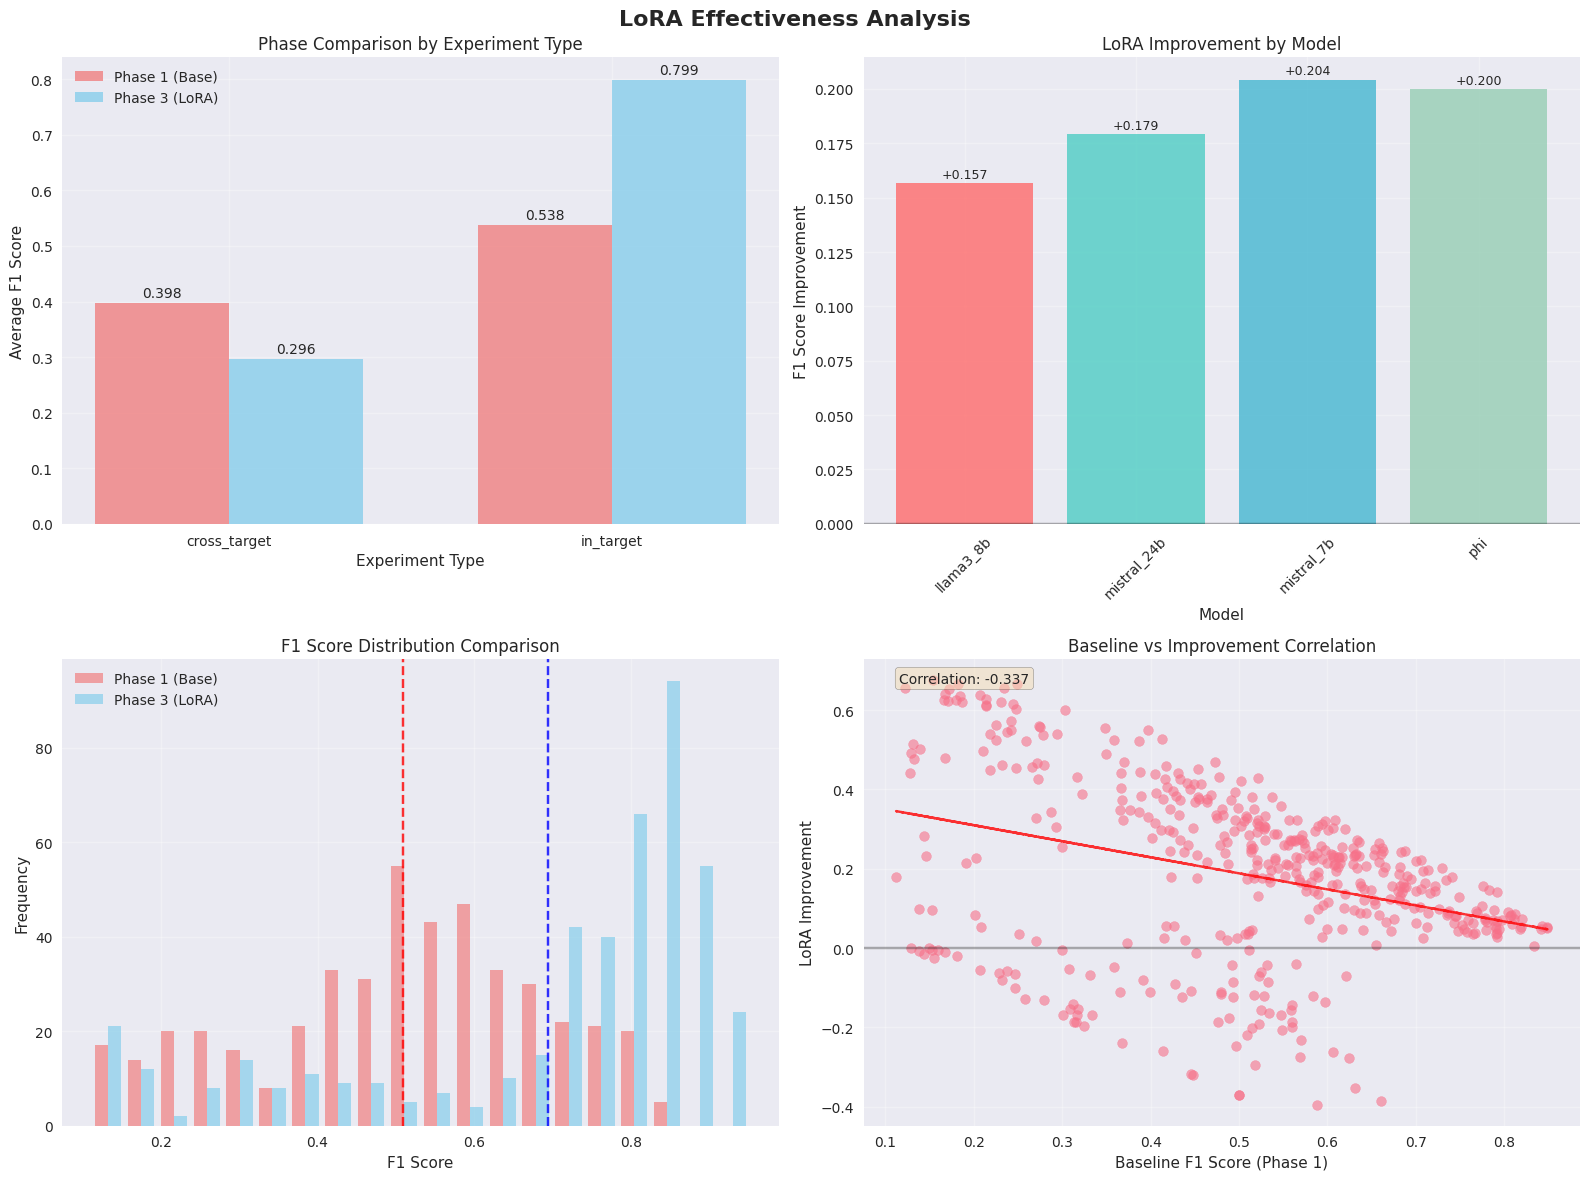

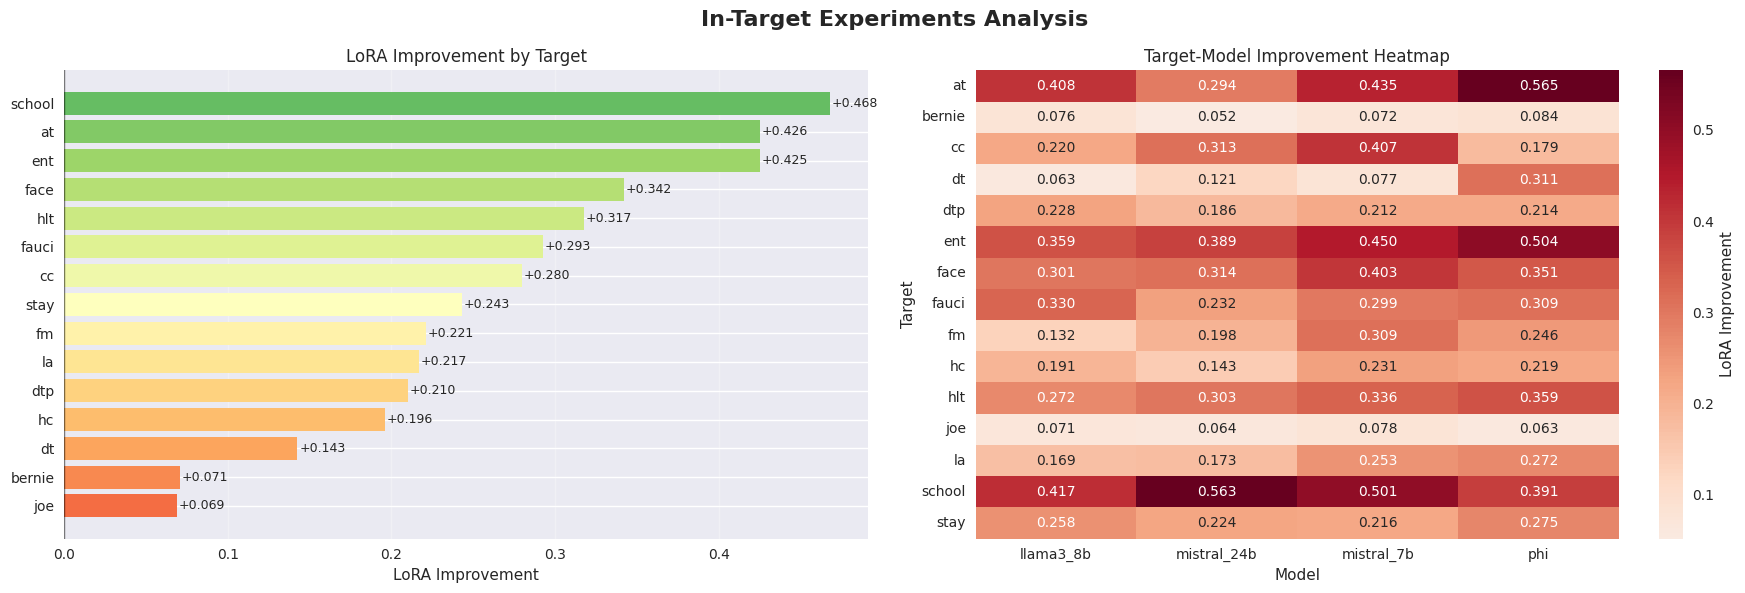

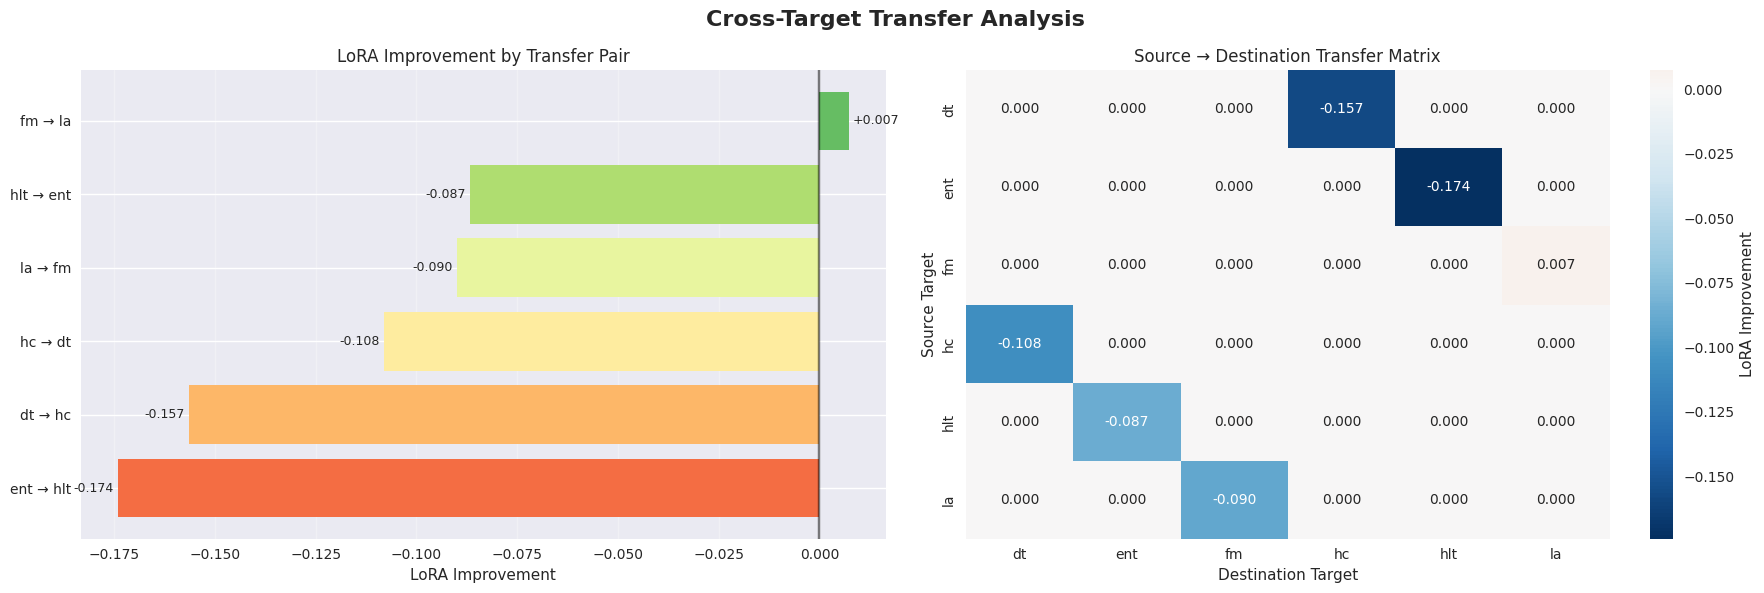

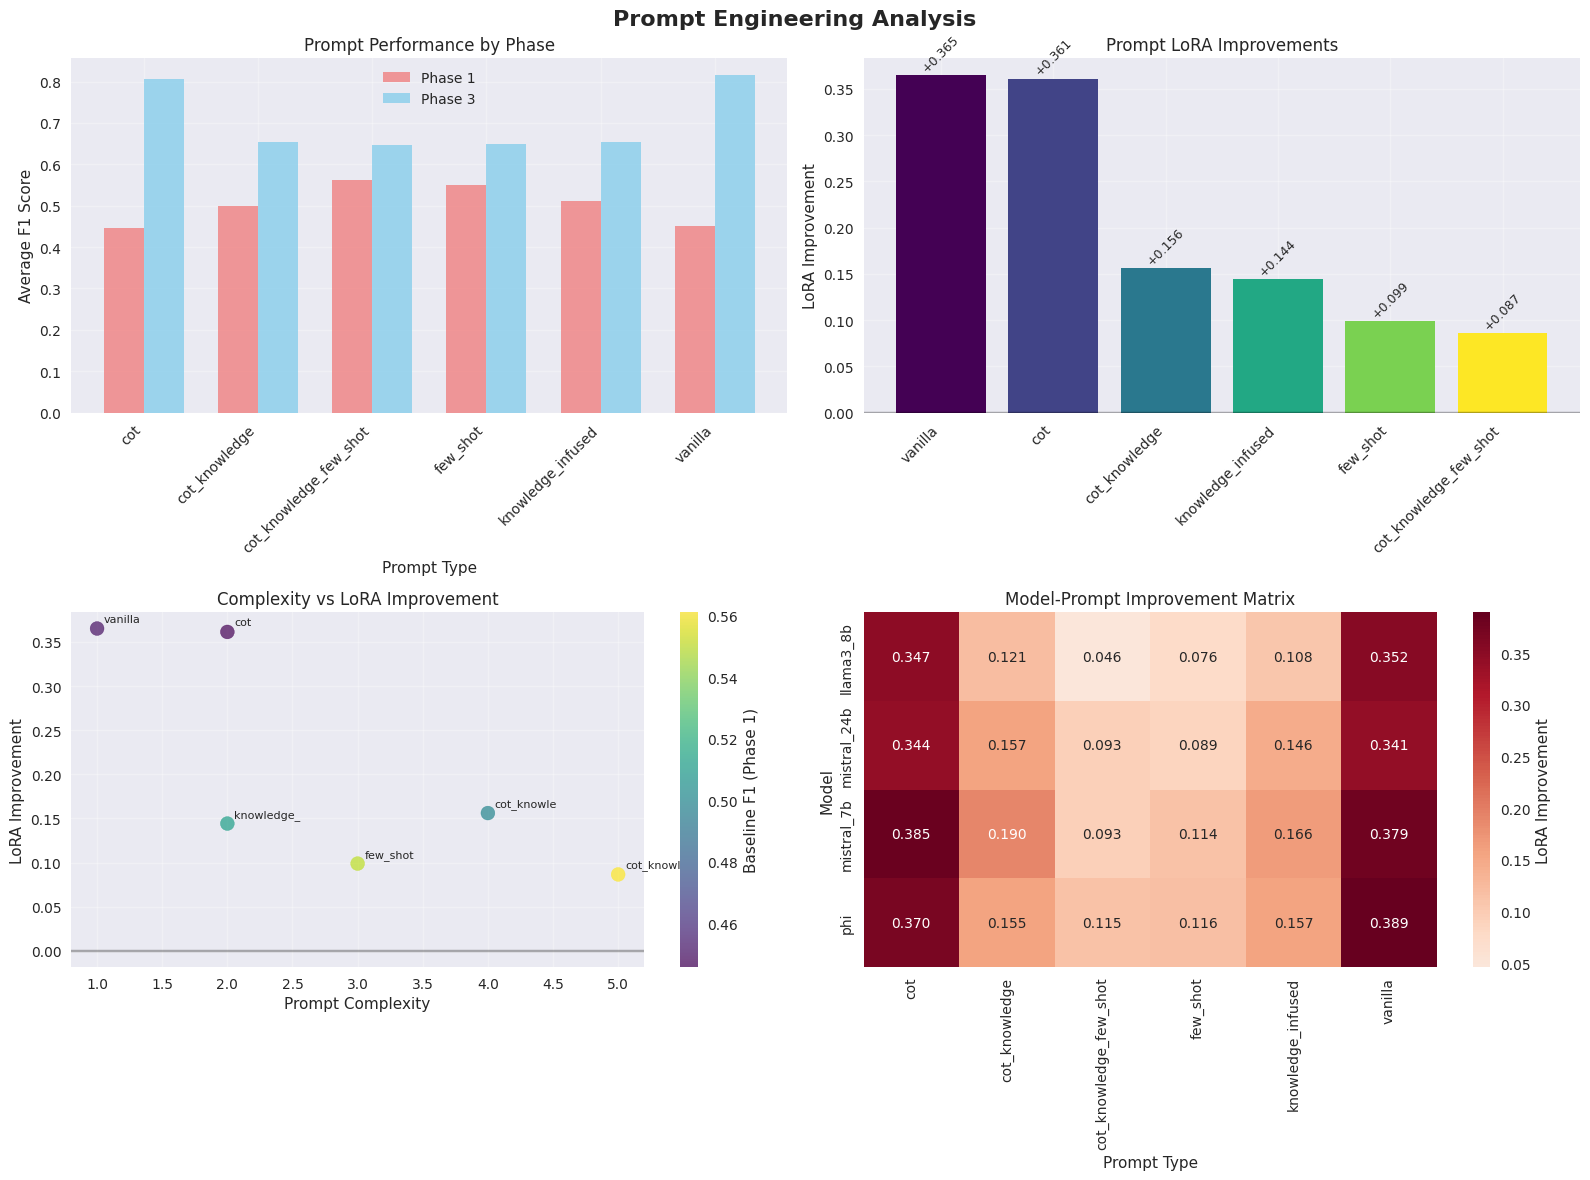

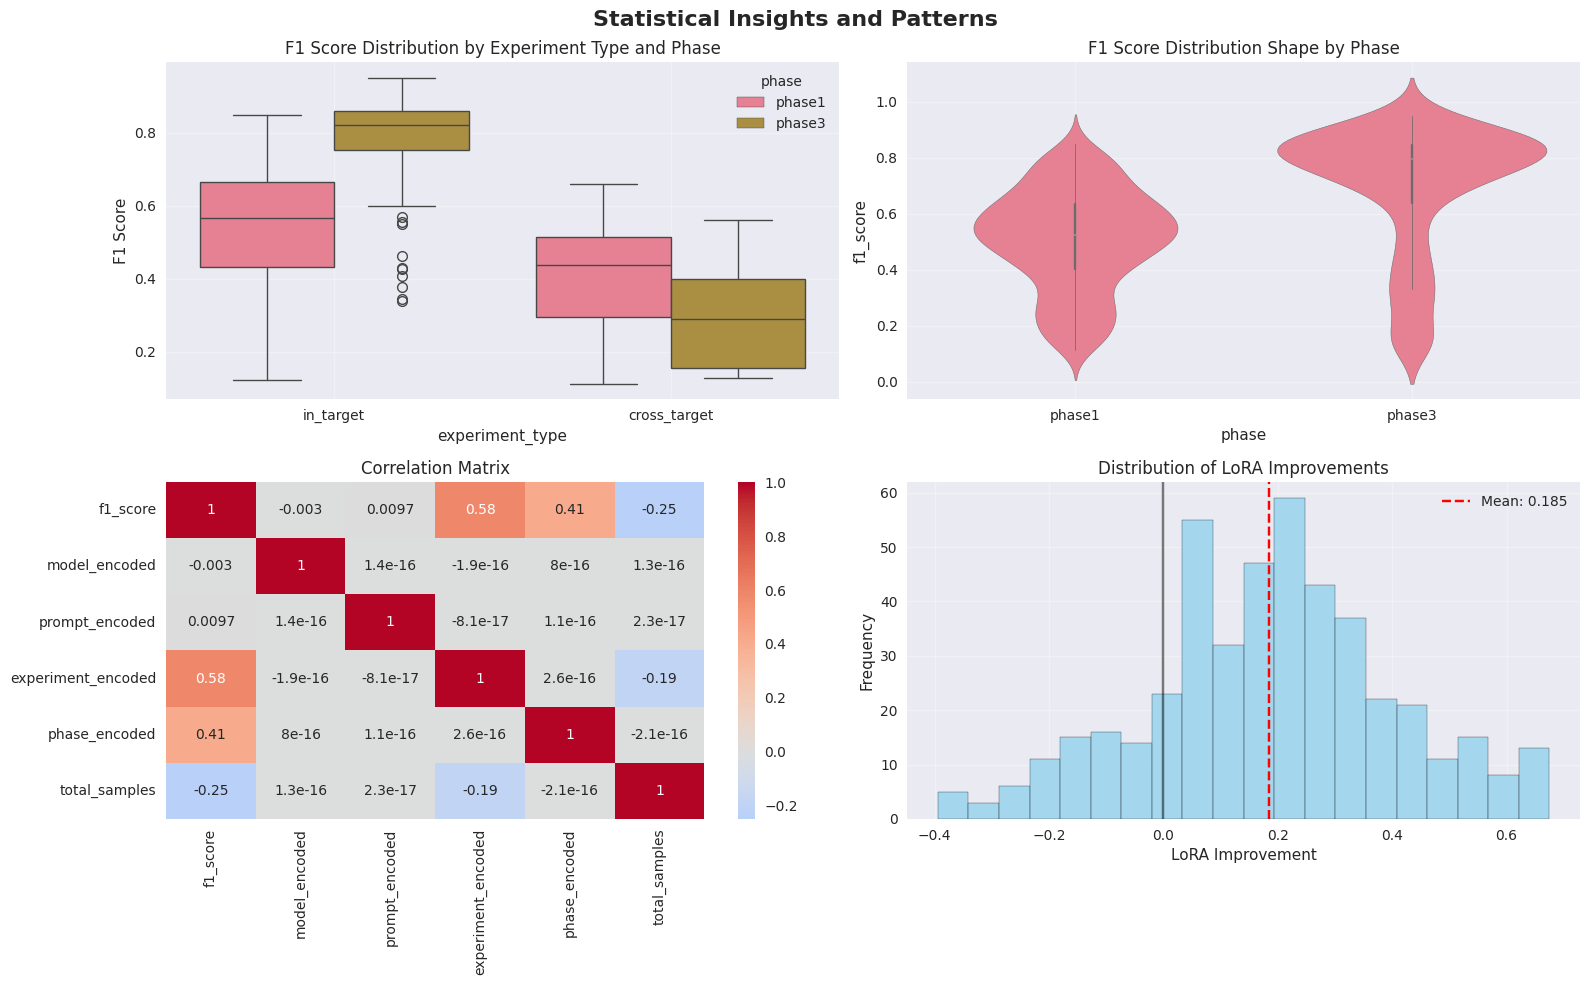

✨ All visualizations created successfully!

📊 Visualization Summary:
1. Overall LoRA effectiveness comparison
2. Target-specific and transfer-specific analysis
3. Prompt engineering insights
4. Statistical patterns and distributions


In [15]:
# ==========================================
# INTERESTING VISUALIZATIONS
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# Set style for better looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("🎨 CREATING VISUALIZATIONS...")
print("="*50)

# ==========================================
# 1. OVERALL EFFECTIVENESS COMPARISON
# ==========================================

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('LoRA Effectiveness Analysis', fontsize=16, fontweight='bold')

# 1.1 Overall Phase Comparison by Experiment Type
experiment_phase_data = df.groupby(['experiment_type', 'phase'])['f1_score'].mean().unstack()

x = np.arange(len(experiment_phase_data.index))
width = 0.35

bars1 = ax1.bar(x - width/2, experiment_phase_data['phase1'], width, 
                label='Phase 1 (Base)', alpha=0.8, color='lightcoral')
bars2 = ax1.bar(x + width/2, experiment_phase_data['phase3'], width, 
                label='Phase 3 (LoRA)', alpha=0.8, color='skyblue')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.3f}', ha='center', va='bottom', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.3f}', ha='center', va='bottom', fontsize=10)

ax1.set_xlabel('Experiment Type')
ax1.set_ylabel('Average F1 Score')
ax1.set_title('Phase Comparison by Experiment Type')
ax1.set_xticks(x)
ax1.set_xticklabels(experiment_phase_data.index)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 1.2 Model Performance Comparison
model_phase_data = df.groupby(['model', 'phase'])['f1_score'].mean().unstack()
model_improvements = model_phase_data['phase3'] - model_phase_data['phase1']

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
bars = ax2.bar(model_improvements.index, model_improvements.values, 
               color=colors, alpha=0.8)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.001,
             f'{height:+.3f}', ha='center', va='bottom', fontsize=9)

ax2.set_xlabel('Model')
ax2.set_ylabel('F1 Score Improvement')
ax2.set_title('LoRA Improvement by Model')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# 1.3 Distribution Comparison
phase1_scores = df[df['phase'] == 'phase1']['f1_score']
phase3_scores = df[df['phase'] == 'phase3']['f1_score']

ax3.hist([phase1_scores, phase3_scores], bins=20, alpha=0.7, 
         label=['Phase 1 (Base)', 'Phase 3 (LoRA)'], color=['lightcoral', 'skyblue'])
ax3.set_xlabel('F1 Score')
ax3.set_ylabel('Frequency')
ax3.set_title('F1 Score Distribution Comparison')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Add mean lines
ax3.axvline(phase1_scores.mean(), color='red', linestyle='--', alpha=0.8, 
           label=f'Phase 1 Mean: {phase1_scores.mean():.3f}')
ax3.axvline(phase3_scores.mean(), color='blue', linestyle='--', alpha=0.8,
           label=f'Phase 3 Mean: {phase3_scores.mean():.3f}')

# 1.4 Improvement vs Baseline Correlation
baseline_vs_improvement = []
for _, row in df[df['phase'] == 'phase3'].iterrows():
    # Find matching baseline
    baseline_row = df[
        (df['phase'] == 'phase1') & 
        (df['model'] == row['model']) & 
        (df['prompt_type'] == row['prompt_type']) & 
        (df['experiment_type'] == row['experiment_type']) &
        (df['target'] == row['target']) &
        (df['source_target'] == row['source_target']) &
        (df['dest_target'] == row['dest_target'])
    ]
    
    if not baseline_row.empty:
        baseline_score = baseline_row['f1_score'].iloc[0]
        improvement = row['f1_score'] - baseline_score
        baseline_vs_improvement.append((baseline_score, improvement))

if baseline_vs_improvement:
    baselines, improvements = zip(*baseline_vs_improvement)
    ax4.scatter(baselines, improvements, alpha=0.6, s=50)
    ax4.set_xlabel('Baseline F1 Score (Phase 1)')
    ax4.set_ylabel('LoRA Improvement')
    ax4.set_title('Baseline vs Improvement Correlation')
    ax4.grid(True, alpha=0.3)
    ax4.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    # Add trend line
    z = np.polyfit(baselines, improvements, 1)
    p = np.poly1d(z)
    ax4.plot(baselines, p(baselines), "r--", alpha=0.8)
    
    # Calculate correlation
    correlation = np.corrcoef(baselines, improvements)[0,1]
    ax4.text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
             transform=ax4.transAxes, bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# ==========================================
# 2. TARGET-SPECIFIC ANALYSIS
# ==========================================

# Separate in-target and cross-target for detailed analysis
in_target_df = df[df['experiment_type'] == 'in_target'].copy()
cross_target_df = df[df['experiment_type'] == 'cross_target'].copy()

# 2.1 In-Target Analysis
if not in_target_df.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('In-Target Experiments Analysis', fontsize=16, fontweight='bold')
    
    # Target improvements
    target_analysis = in_target_df.groupby(['target', 'phase'])['f1_score'].mean().unstack()
    target_improvements = target_analysis['phase3'] - target_analysis['phase1']
    target_improvements = target_improvements.dropna().sort_values(ascending=True)
    
    # Horizontal bar chart for better readability
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(target_improvements)))
    bars = ax1.barh(range(len(target_improvements)), target_improvements.values, color=colors)
    ax1.set_yticks(range(len(target_improvements)))
    ax1.set_yticklabels(target_improvements.index)
    ax1.set_xlabel('LoRA Improvement')
    ax1.set_title('LoRA Improvement by Target')
    ax1.grid(True, alpha=0.3, axis='x')
    ax1.axvline(x=0, color='black', linestyle='-', alpha=0.5)
    
    # Add value labels
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax1.text(width + 0.001 if width >= 0 else width - 0.001, bar.get_y() + bar.get_height()/2,
                f'{width:+.3f}', ha='left' if width >= 0 else 'right', va='center', fontsize=9)
    
    # Target performance heatmap by model
    target_model_data = in_target_df.groupby(['target', 'model', 'phase'])['f1_score'].mean().unstack()
    improvements_pivot = target_model_data['phase3'] - target_model_data['phase1']
    improvements_heatmap = improvements_pivot.unstack().fillna(0)
    
    if not improvements_heatmap.empty:
        sns.heatmap(improvements_heatmap, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
                   ax=ax2, cbar_kws={'label': 'LoRA Improvement'})
        ax2.set_title('Target-Model Improvement Heatmap')
        ax2.set_xlabel('Model')
        ax2.set_ylabel('Target')
    
    plt.tight_layout()
    plt.show()

# 2.2 Cross-Target Analysis  
if not cross_target_df.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('Cross-Target Transfer Analysis', fontsize=16, fontweight='bold')
    
    # Transfer pair improvements
    cross_target_df['transfer_pair'] = cross_target_df['source_target'] + ' → ' + cross_target_df['dest_target']
    pair_analysis = cross_target_df.groupby(['transfer_pair', 'phase'])['f1_score'].mean().unstack()
    pair_improvements = pair_analysis['phase3'] - pair_analysis['phase1']
    pair_improvements = pair_improvements.dropna().sort_values(ascending=True)
    
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(pair_improvements)))
    bars = ax1.barh(range(len(pair_improvements)), pair_improvements.values, color=colors)
    ax1.set_yticks(range(len(pair_improvements)))
    ax1.set_yticklabels(pair_improvements.index)
    ax1.set_xlabel('LoRA Improvement')
    ax1.set_title('LoRA Improvement by Transfer Pair')
    ax1.grid(True, alpha=0.3, axis='x')
    ax1.axvline(x=0, color='black', linestyle='-', alpha=0.5)
    
    # Add value labels
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax1.text(width + 0.001 if width >= 0 else width - 0.001, bar.get_y() + bar.get_height()/2,
                f'{width:+.3f}', ha='left' if width >= 0 else 'right', va='center', fontsize=9)
    
    # Transfer matrix
    transfer_matrix = cross_target_df.groupby(['source_target', 'dest_target', 'phase'])['f1_score'].mean().unstack()
    transfer_improvements = transfer_matrix['phase3'] - transfer_matrix['phase1']
    transfer_pivot = transfer_improvements.unstack().fillna(0)
    
    if not transfer_pivot.empty:
        sns.heatmap(transfer_pivot, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
                   ax=ax2, cbar_kws={'label': 'LoRA Improvement'})
        ax2.set_title('Source → Destination Transfer Matrix')
        ax2.set_xlabel('Destination Target')
        ax2.set_ylabel('Source Target')
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 3. PROMPT ANALYSIS VISUALIZATIONS
# ==========================================

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Prompt Engineering Analysis', fontsize=16, fontweight='bold')

# 3.1 Prompt Performance by Phase
prompt_phase_data = df.groupby(['prompt_type', 'phase'])['f1_score'].mean().unstack()

x = np.arange(len(prompt_phase_data.index))
width = 0.35

bars1 = ax1.bar(x - width/2, prompt_phase_data['phase1'], width, 
                label='Phase 1', alpha=0.8, color='lightcoral')
bars2 = ax1.bar(x + width/2, prompt_phase_data['phase3'], width, 
                label='Phase 3', alpha=0.8, color='skyblue')

ax1.set_xlabel('Prompt Type')
ax1.set_ylabel('Average F1 Score')
ax1.set_title('Prompt Performance by Phase')
ax1.set_xticks(x)
ax1.set_xticklabels(prompt_phase_data.index, rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 3.2 Prompt Improvements
prompt_improvements = prompt_phase_data['phase3'] - prompt_phase_data['phase1']
prompt_improvements = prompt_improvements.dropna().sort_values(ascending=False)

colors = plt.cm.viridis(np.linspace(0, 1, len(prompt_improvements)))
bars = ax2.bar(range(len(prompt_improvements)), prompt_improvements.values, color=colors)
ax2.set_xticks(range(len(prompt_improvements)))
ax2.set_xticklabels(prompt_improvements.index, rotation=45, ha='right')
ax2.set_ylabel('LoRA Improvement')
ax2.set_title('Prompt LoRA Improvements')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add value labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.001 if height >= 0 else height - 0.002,
             f'{height:+.3f}', ha='center', va='bottom' if height >= 0 else 'top', 
             fontsize=9, rotation=45)

# 3.3 Prompt Complexity vs Performance
prompt_hierarchy = {
    'vanilla': 1, 'knowledge_infused': 2, 'few_shot': 3,
    'cot': 2, 'cot_knowledge': 4, 'cot_knowledge_few_shot': 5
}

complexity_data = []
for prompt in df['prompt_type'].unique():
    if prompt in prompt_hierarchy:
        complexity = prompt_hierarchy[prompt]
        phase1_score = df[(df['prompt_type'] == prompt) & (df['phase'] == 'phase1')]['f1_score'].mean()
        phase3_score = df[(df['prompt_type'] == prompt) & (df['phase'] == 'phase3')]['f1_score'].mean()
        if not pd.isna(phase1_score) and not pd.isna(phase3_score):
            improvement = phase3_score - phase1_score
            complexity_data.append((complexity, phase1_score, phase3_score, improvement, prompt))

if complexity_data:
    complexities, phase1_scores, phase3_scores, improvements, prompt_names = zip(*complexity_data)
    
    # Scatter plot with different colors for each prompt
    scatter = ax3.scatter(complexities, improvements, c=phase1_scores, s=100, 
                         alpha=0.7, cmap='viridis')
    
    # Add labels for each point
    for i, prompt in enumerate(prompt_names):
        ax3.annotate(prompt[:10], (complexities[i], improvements[i]), 
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    ax3.set_xlabel('Prompt Complexity')
    ax3.set_ylabel('LoRA Improvement')
    ax3.set_title('Complexity vs LoRA Improvement')
    ax3.grid(True, alpha=0.3)
    ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax3)
    cbar.set_label('Baseline F1 (Phase 1)')

# 3.4 Model-Prompt Interaction Heatmap
model_prompt_data = df.groupby(['model', 'prompt_type', 'phase'])['f1_score'].mean().unstack()
model_prompt_improvements = model_prompt_data['phase3'] - model_prompt_data['phase1']
model_prompt_pivot = model_prompt_improvements.unstack().fillna(0)

if not model_prompt_pivot.empty:
    sns.heatmap(model_prompt_pivot, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
               ax=ax4, cbar_kws={'label': 'LoRA Improvement'})
    ax4.set_title('Model-Prompt Improvement Matrix')
    ax4.set_xlabel('Prompt Type')
    ax4.set_ylabel('Model')

plt.tight_layout()
plt.show()

# ==========================================
# 4. STATISTICAL INSIGHTS VISUALIZATION
# ==========================================

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Statistical Insights and Patterns', fontsize=16, fontweight='bold')

# 4.1 Box plot comparison by experiment type and phase
df_melted = df.melt(id_vars=['experiment_type', 'phase'], value_vars=['f1_score'], 
                    var_name='metric', value_name='score')

sns.boxplot(data=df_melted, x='experiment_type', y='score', hue='phase', ax=ax1)
ax1.set_title('F1 Score Distribution by Experiment Type and Phase')
ax1.set_ylabel('F1 Score')
ax1.grid(True, alpha=0.3)

# 4.2 Violin plot for detailed distribution
sns.violinplot(data=df, x='phase', y='f1_score', ax=ax2)
ax2.set_title('F1 Score Distribution Shape by Phase')
ax2.grid(True, alpha=0.3)

# 4.3 Correlation matrix of different factors
# Create numerical encoding for categorical variables
df_corr = df.copy()
df_corr['model_encoded'] = pd.Categorical(df_corr['model']).codes
df_corr['prompt_encoded'] = pd.Categorical(df_corr['prompt_type']).codes
df_corr['experiment_encoded'] = pd.Categorical(df_corr['experiment_type']).codes
df_corr['phase_encoded'] = pd.Categorical(df_corr['phase']).codes

correlation_matrix = df_corr[['f1_score', 'model_encoded', 'prompt_encoded', 
                             'experiment_encoded', 'phase_encoded', 'total_samples']].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, ax=ax3)
ax3.set_title('Correlation Matrix')

# 4.4 Performance improvement distribution
all_improvements = []
for _, row in df[df['phase'] == 'phase3'].iterrows():
    baseline_row = df[
        (df['phase'] == 'phase1') & 
        (df['model'] == row['model']) & 
        (df['prompt_type'] == row['prompt_type']) & 
        (df['experiment_type'] == row['experiment_type']) &
        (df['target'] == row['target']) &
        (df['source_target'] == row['source_target']) &
        (df['dest_target'] == row['dest_target'])
    ]
    
    if not baseline_row.empty:
        improvement = row['f1_score'] - baseline_row['f1_score'].iloc[0]
        all_improvements.append(improvement)

if all_improvements:
    ax4.hist(all_improvements, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    ax4.axvline(np.mean(all_improvements), color='red', linestyle='--', 
               label=f'Mean: {np.mean(all_improvements):.3f}')
    ax4.axvline(0, color='black', linestyle='-', alpha=0.5)
    ax4.set_xlabel('LoRA Improvement')
    ax4.set_ylabel('Frequency')
    ax4.set_title('Distribution of LoRA Improvements')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✨ All visualizations created successfully!")
print("\n📊 Visualization Summary:")
print("1. Overall LoRA effectiveness comparison")
print("2. Target-specific and transfer-specific analysis")
print("3. Prompt engineering insights")
print("4. Statistical patterns and distributions")